In [86]:
import sys
import numpy as np
import matplotlib.pyplot as plt

import astropy
import astropy.units as u
import astropy.coordinates as coord

import gala
import gala.dynamics as gd
import gala.potential as gp

from galstreams import MWStreams

from scipy.optimize import least_squares

In [87]:
coord.galactocentric_frame_defaults.set("v4.0")

galcen_frame = coord.Galactocentric()

print(galcen_frame)

<Galactocentric Frame (galcen_coord=<ICRS Coordinate: (ra, dec) in deg
    (266.4051, -28.936175)>, galcen_distance=8.122 kpc, galcen_v_sun=(12.9, 245.6, 7.78) km / s, z_sun=20.8 pc, roll=0.0 deg)>


In [88]:
mw = gp.MilkyWayPotential(version="v2")

print(mw)

MilkyWayPotential


In [89]:
for name, component in mw.items():
    print(f"{name}:")
    print(component)
    print()

disk:
MN3ExponentialDiskPotential

bulge:
HernquistPotential

nucleus:
HernquistPotential

halo:
NFWPotential



In [90]:
radii = np.array([5, 8, 15, 30]) * u.kpc

for r in radii:
    pos = np.array([r.value, 0.0, 0.0]) * u.kpc
    vel = np.zeros(3) * u.km / u.s

    w = gd.PhaseSpacePosition(
        pos=pos,
        vel=vel,
    )

    phi = mw.energy(w)

    print(f"r = {r:>5}:  Φ = {phi}")

r =   5.0 kpc:  Φ = [-0.18904924] kpc2 / Myr2
r =   8.0 kpc:  Φ = [-0.16332274] kpc2 / Myr2
r =  15.0 kpc:  Φ = [-0.13028979] kpc2 / Myr2
r =  30.0 kpc:  Φ = [-0.09809455] kpc2 / Myr2


Before constructing the GD-1 model, we verify that the adopted
Milky Way potential and orbit integrator behave correctly for a
simple bound test orbit.

This orbit is **not intended to represent GD-1**.

The test uses:
- position: (8, 0, 0) kpc
- velocity: (0, 220, 0) km/s
- integration time: 200 Myr
- timestep: 1 Myr

In [91]:
radii = np.array([5, 8, 15, 30]) * u.kpc

for R in radii:
    pos = np.array([R.value, 0.0, 0.0]) * u.kpc

    acc = mw.acceleration(pos)

    a_R = acc[0].to(u.kpc / u.Myr**2).value.item() * u.kpc / u.Myr**2

    v_c = np.sqrt(R * np.abs(a_R))

    print(
        f"R = {R.value:5.1f} kpc: "
        f"a_R = {a_R.value:.6e} kpc/Myr², "
        f"v_c = {v_c.to_value(u.km/u.s):.2f} km/s"
    )

R =   5.0 kpc: a_R = -1.057127e-02 kpc/Myr², v_c = 224.80 km/s
R =   8.0 kpc: a_R = -6.889010e-03 kpc/Myr², v_c = 229.55 km/s
R =  15.0 kpc: a_R = -3.298387e-03 kpc/Myr², v_c = 217.49 km/s
R =  30.0 kpc: a_R = -1.453977e-03 kpc/Myr², v_c = 204.21 km/s


In [92]:
w0_test = gd.PhaseSpacePosition(
    pos=[8.0, 0.0, 0.0] * u.kpc,
    vel=[0.0, 220.0, 0.0] * u.km/u.s,
)

In [93]:
orbit_test = mw.integrate_orbit(
    w0_test,
    dt=1 * u.Myr,
    t1=0 * u.Myr,
    t2=200 * u.Myr,
)

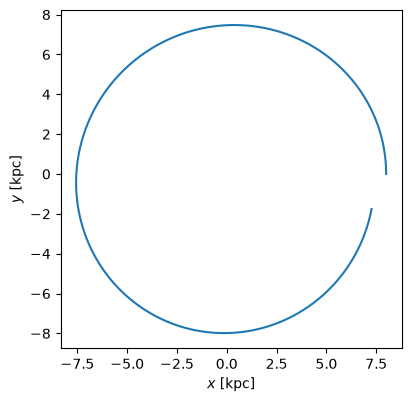

In [94]:
fig = orbit_test.plot(["x", "y"])
plt.show()

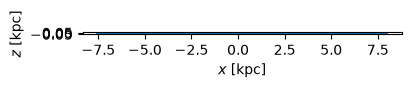

In [95]:
fig = orbit_test.plot(["x", "z"])
plt.show()

In [96]:
x = orbit_test.x.to_value(u.kpc)
y = orbit_test.y.to_value(u.kpc)
z = orbit_test.z.to_value(u.kpc)

R = np.sqrt(x**2 + y**2)

print(f"R_min = {R.min():.4f} kpc")
print(f"R_max = {R.max():.4f} kpc")
print(f"R_mean = {R.mean():.4f} kpc")

print(f"|z|_max = {np.abs(z).max():.6f} kpc")

R_min = 7.3402 kpc
R_max = 8.0000 kpc
R_mean = 7.7076 kpc
|z|_max = 0.000000 kpc


In [97]:
v_x = orbit_test.v_x.to_value(u.km/u.s)
v_y = orbit_test.v_y.to_value(u.km/u.s)
v_z = orbit_test.v_z.to_value(u.km/u.s)

speed = np.sqrt(v_x**2 + v_y**2 + v_z**2)

print(f"v_min  = {speed.min():.3f} km/s")
print(f"v_max  = {speed.max():.3f} km/s")
print(f"v_mean = {speed.mean():.3f} km/s")

v_min  = 220.000 km/s
v_max  = 239.777 km/s
v_mean = 228.759 km/s


In [98]:
energy = orbit_test.energy()

energy_values = energy.to_value(energy.unit)

relative_energy_error = (
    (energy_values - energy_values[0])
    / np.abs(energy_values[0])
)

print(f"Initial energy: {energy_values[0]:.10e} {energy.unit}")
print(f"Final energy:   {energy_values[-1]:.10e} {energy.unit}")
print(f"Max |ΔE/E|:     {np.max(np.abs(relative_energy_error)):.3e}")

Initial energy: -1.3801098829e-01 kpc2 / Myr2
Final energy:   -1.3801181994e-01 kpc2 / Myr2
Max |ΔE/E|:     8.144e-06


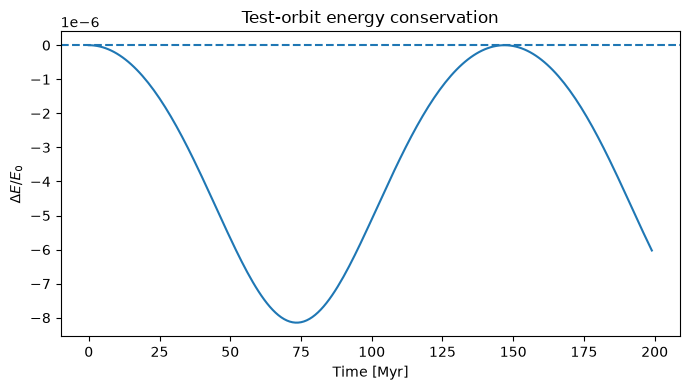

In [99]:
plt.figure(figsize=(7, 4))

plt.plot(
    orbit_test.t.to_value(u.Myr),
    relative_energy_error
)

plt.axhline(0, linestyle="--")

plt.xlabel("Time [Myr]")
plt.ylabel(r"$\Delta E/E_0$")
plt.title("Test-orbit energy conservation")

plt.tight_layout()
plt.show()

# GD-1 observational reference

The numerical sanity checks above passed. We now construct the
GD-1 dynamical baseline using an observationally motivated
phase-space track.

In [100]:
from astropy.table import Table

gd1 = Table.read(
    "/home/darxsouls/research/stellar_streams/data/gd-1/gd1_tbl_with_memb_prob.mrt",
    format="ascii.mrt"
)

print(gd1)

     source_id              ra         ... CMD_cut       memb_prob       
                           deg         ...                               
------------------- ------------------ ... ------- ----------------------
 576748068435698048 134.13841688083966 ...       1 2.2540250512219704e-93
 576748244530543488 134.16732705372561 ...       0 1.1556621439327705e-70
 576750301818727936 134.22981963824748 ...       0 1.0401231848330938e-05
 576760064280542592 134.14547166643905 ...       0  5.345798693734369e-63
 576760300502579328  134.1113034294974 ...       1 4.4983443168508237e-60
 576760334862325504 134.12016082647645 ...       0  6.697992037256874e-07
 576760437941539712  134.1564021078413 ...       0 1.6075815010313644e-17
 576760884618149248 134.16590122401283 ...       0  8.749130430123883e-26
 576761262575264896 134.04034521551716 ...       0 3.0337614857179005e-89
                ...                ... ...     ...                    ...
5763857862263680640 132.37620927425922

In [101]:
print(gd1.colnames)

['source_id', 'ra', 'dec', 'parallax', 'e_parallax', 'pmra', 'pmdec', 'e_pmra', 'e_pmdec', 'g0', 'r0', 'i0', 'phi1', 'phi2', 'pm1', 'pm2', 'e_pm1', 'e_pm2', 'rv', 'e_rv', 'feh', 'e_feh', 'alphafe', 'e_alphafe', 'CMD_cut', 'memb_prob']


In [102]:
print(gd1.info)

<Table length=466571>
   name     dtype    unit                  description                n_bad
---------- ------- -------- ----------------------------------------- -----
 source_id   int64                                 Gaia source id (1)     0
        ra float64      deg  Right Ascension, decimal deg (J2000) (1)     0
       dec float64      deg      Declination, decimal deg (J2000) (1)     0
  parallax float64   arcsec                              Parallax (1)     0
e_parallax float64   arcsec               Uncertainty in parallax (1)     0
      pmra float64 mas / yr  Proper motion (PM) along ra*cos(dec) (1)     0
     pmdec float64 mas / yr                          PM along dec (1)     0
    e_pmra float64 mas / yr   Uncertainty in PM along ra*cos(dec) (1)     0
   e_pmdec float64 mas / yr           Uncertainty in PM along dec (1)     0
        g0 float64      mag Extinction corrected g band magnitude (2)     0
        r0 float64      mag Extinction corrected r band magnitude 

from the paper we use the following cuts

membership probability > 0.5
AND
CMD_cut == 1

In [103]:
members = gd1[
    (gd1["memb_prob"] > 0.5) &
    (gd1["CMD_cut"] == 1)
]

print(f"Selected GD-1 members: {len(members):,}")

Selected GD-1 members: 1,689


In [104]:
p = np.asarray(members["memb_prob"])

print(f"Minimum membership probability: {np.min(p):.4f}")
print(f"Median membership probability:  {np.median(p):.4f}")
print(f"Maximum membership probability: {np.max(p):.4f}")

Minimum membership probability: 0.5009
Median membership probability:  0.9714
Maximum membership probability: 1.0000


Phase-space Covergae

In [105]:
for col in ["phi1", "phi2", "pm1", "pm2", "rv"]:
    x = np.asarray(members[col])

    finite = np.isfinite(x)

    print(
        f"{col:>5s}: "
        f"N={finite.sum():4d}, "
        f"min={np.nanmin(x):10.3f}, "
        f"max={np.nanmax(x):10.3f}, "
        f"median={np.nanmedian(x):10.3f}"
    )

 phi1: N=1689, min=   -87.161, max=    14.356, median=   -35.552
 phi2: N=1689, min=    -4.010, max=     2.546, median=    -0.187
  pm1: N=1689, min=   -14.689, max=    -5.522, median=   -12.469
  pm2: N=1689, min=    -5.218, max=     0.393, median=    -3.079
   rv: N=1689, min=  -361.209, max=   271.462, median=     0.000


Stream Morphology

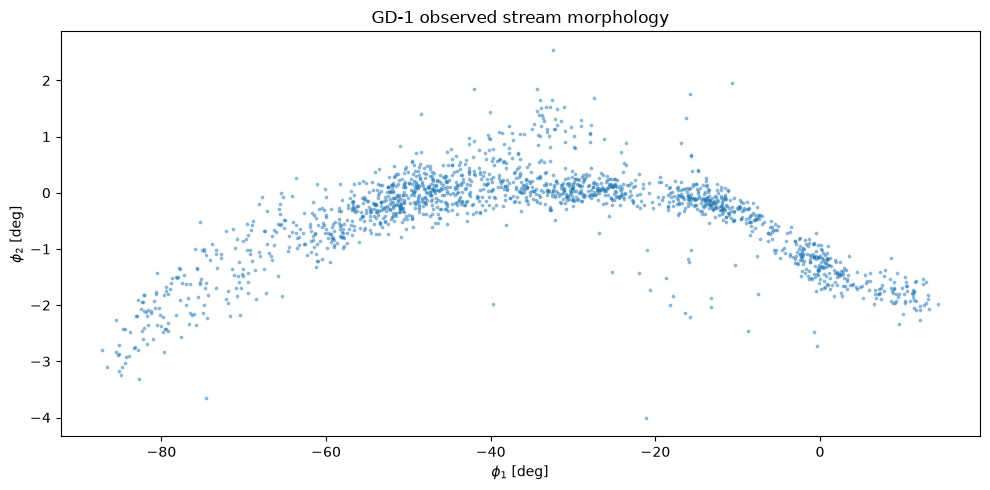

In [106]:
phi1 = np.asarray(members["phi1"])
phi2 = np.asarray(members["phi2"])

plt.figure(figsize=(10, 5))

plt.scatter(
    phi1,
    phi2,
    s=3,
    alpha=0.4
)

plt.xlabel(r"$\phi_1$ [deg]")
plt.ylabel(r"$\phi_2$ [deg]")
plt.title("GD-1 observed stream morphology")

plt.tight_layout()
plt.show()

Proper motion along the stream

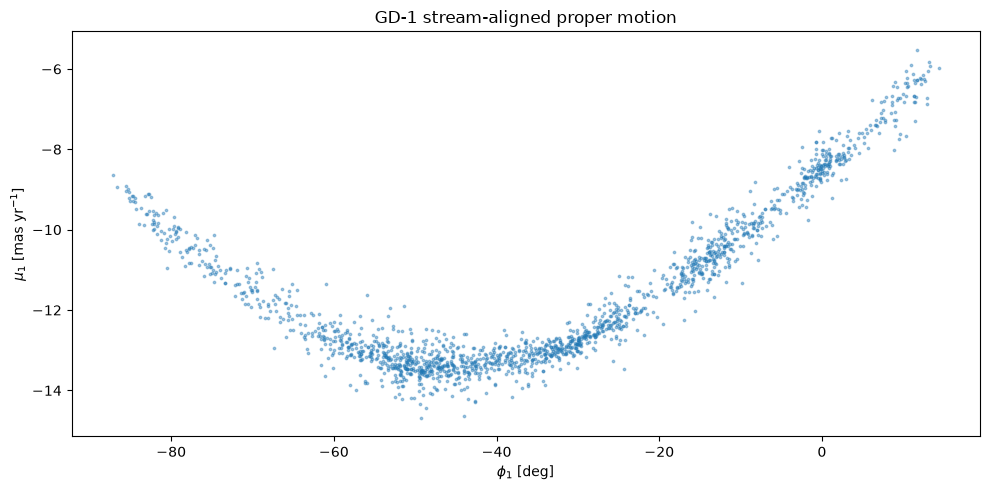

In [107]:
pm1 = np.asarray(members["pm1"])

plt.figure(figsize=(10, 5))

plt.scatter(
    phi1,
    pm1,
    s=3,
    alpha=0.4
)

plt.xlabel(r"$\phi_1$ [deg]")
plt.ylabel(r"$\mu_1$ [mas yr$^{-1}$]")
plt.title("GD-1 stream-aligned proper motion")

plt.tight_layout()
plt.show()

Proper motion perpendicular to the stream

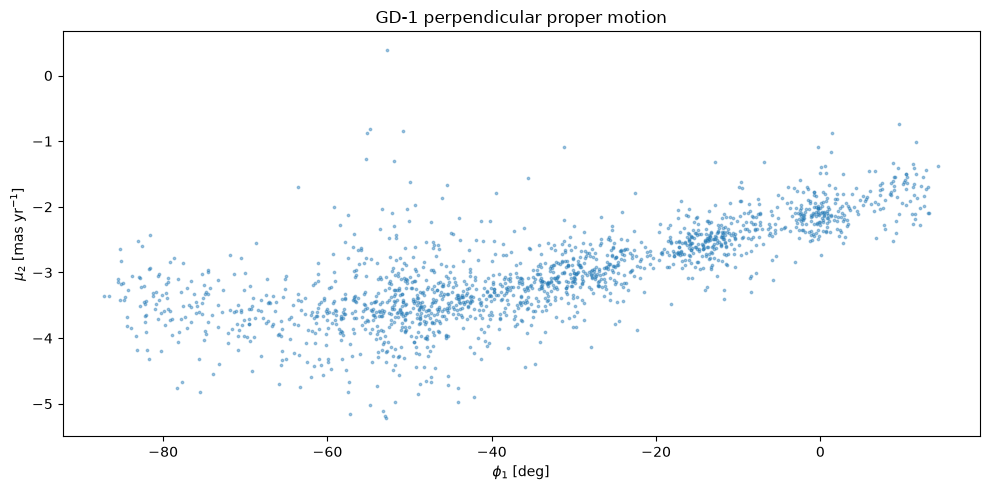

In [108]:
pm2 = np.asarray(members["pm2"])

plt.figure(figsize=(10, 5))

plt.scatter(
    phi1,
    pm2,
    s=3,
    alpha=0.4
)

plt.xlabel(r"$\phi_1$ [deg]")
plt.ylabel(r"$\mu_2$ [mas yr$^{-1}$]")
plt.title("GD-1 perpendicular proper motion")

plt.tight_layout()
plt.show()

Radial velocity

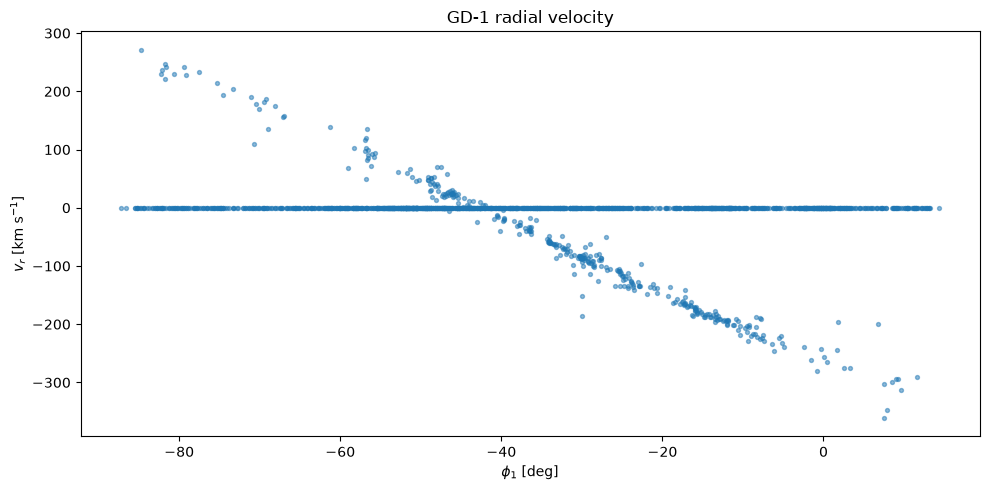

In [109]:
rv = np.asarray(members["rv"])

finite_rv = np.isfinite(rv)

plt.figure(figsize=(10, 5))

plt.scatter(
    phi1[finite_rv],
    rv[finite_rv],
    s=8,
    alpha=0.5
)

plt.xlabel(r"$\phi_1$ [deg]")
plt.ylabel(r"$v_r$ [km s$^{-1}$]")
plt.title("GD-1 radial velocity")

plt.tight_layout()
plt.show()

In [110]:
for col in ["e_pm1", "e_pm2", "e_rv", "e_parallax"]:
    x = np.asarray(members[col])
    finite = np.isfinite(x)

    print(
        f"{col:>10s}: "
        f"N={finite.sum():4d}, "
        f"median={np.nanmedian(x):.4f}, "
        f"90th percentile={np.nanpercentile(x, 90):.4f}"
    )

     e_pm1: N=1689, median=0.2344, 90th percentile=0.5086
     e_pm2: N=1689, median=0.2977, 90th percentile=0.7007
      e_rv: N=1689, median=10000.0000, 90th percentile=10000.0000
e_parallax: N=1689, median=0.2981, 90th percentile=0.6483


In [111]:
# Inspect potentially missing / placeholder values
for col in ["rv", "e_rv", "pm1", "pm2", "e_pm1", "e_pm2",
            "parallax", "e_parallax"]:

    x = np.asarray(members[col])

    print(f"\n{col}")
    print(f"  min       = {np.nanmin(x):.6g}")
    print(f"  max       = {np.nanmax(x):.6g}")
    print(f"  median    = {np.nanmedian(x):.6g}")
    print(f"  zeros     = {np.count_nonzero(x == 0):,}")
    print(f"  -999      = {np.count_nonzero(x == -999):,}")
    print(f"  -10000    = {np.count_nonzero(x == -10000):,}")
    print(f"  NaN       = {np.count_nonzero(~np.isfinite(x)):,}")


rv
  min       = -361.209
  max       = 271.462
  median    = 0
  zeros     = 1,336
  -999      = 0
  -10000    = 0
  NaN       = 0

e_rv
  min       = 0.0483977
  max       = 10000
  median    = 10000
  zeros     = 0
  -999      = 0
  -10000    = 0
  NaN       = 0

pm1
  min       = -14.6888
  max       = -5.52214
  median    = -12.4687
  zeros     = 0
  -999      = 0
  -10000    = 0
  NaN       = 0

pm2
  min       = -5.21782
  max       = 0.392765
  median    = -3.07948
  zeros     = 0
  -999      = 0
  -10000    = 0
  NaN       = 0

e_pm1
  min       = 0.00963064
  max       = 1.32873
  median    = 0.234372
  zeros     = 0
  -999      = 0
  -10000    = 0
  NaN       = 0

e_pm2
  min       = 0.0107944
  max       = 2.04688
  median    = 0.297724
  zeros     = 0
  -999      = 0
  -10000    = 0
  NaN       = 0

parallax
  min       = -2.9519
  max       = 0.996039
  median    = 0.106905
  zeros     = 0
  -999      = 0
  -10000    = 0
  NaN       = 0

e_parallax
  min       = 0.011391

In [112]:
rv = np.asarray(members["rv"])
e_rv = np.asarray(members["e_rv"])

print("\nRV diagnostics")
print("----------------")

print("RV == 0:", np.count_nonzero(rv == 0))
print("e_RV == 0:", np.count_nonzero(e_rv == 0))

print("\nSmallest |RV| values:")
idx = np.argsort(np.abs(rv))[:20]

for i in idx:
    print(f"RV = {rv[i]:10.4f}, e_RV = {e_rv[i]:8.4f}")


RV diagnostics
----------------
RV == 0: 1336
e_RV == 0: 0

Smallest |RV| values:
RV =     0.0000, e_RV = 10000.0000
RV =     0.0000, e_RV = 10000.0000
RV =     0.0000, e_RV = 10000.0000
RV =     0.0000, e_RV = 10000.0000
RV =     0.0000, e_RV = 10000.0000
RV =     0.0000, e_RV = 10000.0000
RV =     0.0000, e_RV = 10000.0000
RV =     0.0000, e_RV = 10000.0000
RV =     0.0000, e_RV = 10000.0000
RV =     0.0000, e_RV = 10000.0000
RV =     0.0000, e_RV = 10000.0000
RV =     0.0000, e_RV = 10000.0000
RV =     0.0000, e_RV = 10000.0000
RV =     0.0000, e_RV = 10000.0000
RV =     0.0000, e_RV = 10000.0000
RV =     0.0000, e_RV = 10000.0000
RV =     0.0000, e_RV = 10000.0000
RV =     0.0000, e_RV = 10000.0000
RV =     0.0000, e_RV = 10000.0000
RV =     0.0000, e_RV = 10000.0000


## Radial-velocity availability

The catalog encodes missing radial velocities using:

- rv = 0
- e_rv = 10000 km/s

For the 1,689 selected GD-1 members, this leaves 353 stars
with usable radial-velocity measurements.

Radial velocity is therefore treated as a partially observed
phase-space quantity rather than requiring complete coverage
of the member catalog.

In [113]:
# Identify stars with usable radial velocities
rv = np.asarray(members["rv"])
e_rv = np.asarray(members["e_rv"])

has_rv = e_rv < 10000

print(f"Total GD-1 members: {len(members):,}")
print(f"Members with RV:     {has_rv.sum():,}")
print(f"Members without RV:  {(~has_rv).sum():,}")

Total GD-1 members: 1,689
Members with RV:     353
Members without RV:  1,336


In [114]:
members_rv = members[has_rv]

print(len(members_rv))

353


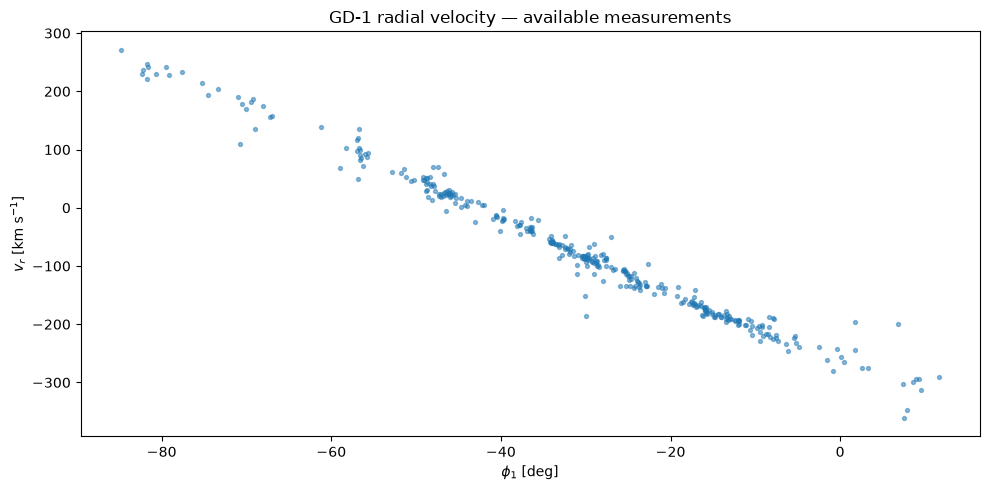

In [115]:
rv = np.asarray(members["rv"])
e_rv = np.asarray(members["e_rv"])

has_rv = e_rv < 10000

plt.figure(figsize=(10, 5))

plt.scatter(
    phi1[has_rv],
    rv[has_rv],
    s=8,
    alpha=0.5
)

plt.xlabel(r"$\phi_1$ [deg]")
plt.ylabel(r"$v_r$ [km s$^{-1}$]")
plt.title("GD-1 radial velocity — available measurements")

plt.tight_layout()
plt.show()

In [116]:
# Final observational coverage summary

columns = ["phi1", "phi2", "pm1", "pm2", "rv"]

print("=" * 60)
print("GD-1 OBSERVATIONAL COVERAGE")
print("=" * 60)

for col in columns:
    x = np.asarray(members[col])

    if col == "rv":
        valid = np.asarray(members["e_rv"]) < 10000
    else:
        valid = np.isfinite(x)

    print(
        f"{col:>5s}: "
        f"{valid.sum():4d} / {len(members):4d} "
        f"({100 * valid.sum() / len(members):6.2f}%)"
    )

GD-1 OBSERVATIONAL COVERAGE
 phi1: 1689 / 1689 (100.00%)
 phi2: 1689 / 1689 (100.00%)
  pm1: 1689 / 1689 (100.00%)
  pm2: 1689 / 1689 (100.00%)
   rv:  353 / 1689 ( 20.90%)


In [117]:
print("\nRV uncertainty statistics:")
print("---------------------------")

rv_err = np.asarray(members_rv["e_rv"])

print(f"Median e_RV : {np.median(rv_err):.3f} km/s")
print(f"Mean e_RV   : {np.mean(rv_err):.3f} km/s")
print(f"Min e_RV    : {np.min(rv_err):.3f} km/s")
print(f"Max e_RV    : {np.max(rv_err):.3f} km/s")


RV uncertainty statistics:
---------------------------
Median e_RV : 4.987 km/s
Mean e_RV   : 7.650 km/s
Min e_RV    : 0.048 km/s
Max e_RV    : 119.206 km/s


### GD-1 phase-space reference

We now construct an observationally motivated phase-space reference
for GD-1.

The observed member catalog provides sky position, parallax, proper
motion, stream-aligned coordinates, and radial velocity. We use these
measurements to characterize the large-scale phase-space track of GD-1.

The observational reference is kept separate from the dynamical model.
It will be used to initialize and validate the unperturbed dynamical
stream rather than forcing the dynamical model to reproduce small-scale
perturbations present in the observations.

In [118]:
# Parallax signal-to-noise
parallax = np.asarray(members["parallax"])
e_parallax = np.asarray(members["e_parallax"])

parallax_snr = parallax / e_parallax

print("Parallax S/N statistics")
print("-----------------------")
print(f"Median : {np.median(parallax_snr):.3f}")
print(f"16th   : {np.percentile(parallax_snr, 16):.3f}")
print(f"84th   : {np.percentile(parallax_snr, 84):.3f}")
print(f"> 3σ   : {np.sum(parallax_snr > 3)}")
print(f"> 5σ   : {np.sum(parallax_snr > 5)}")

Parallax S/N statistics
-----------------------
Median : 0.452
16th   : -0.660
84th   : 1.669
> 3σ   : 77
> 5σ   : 42


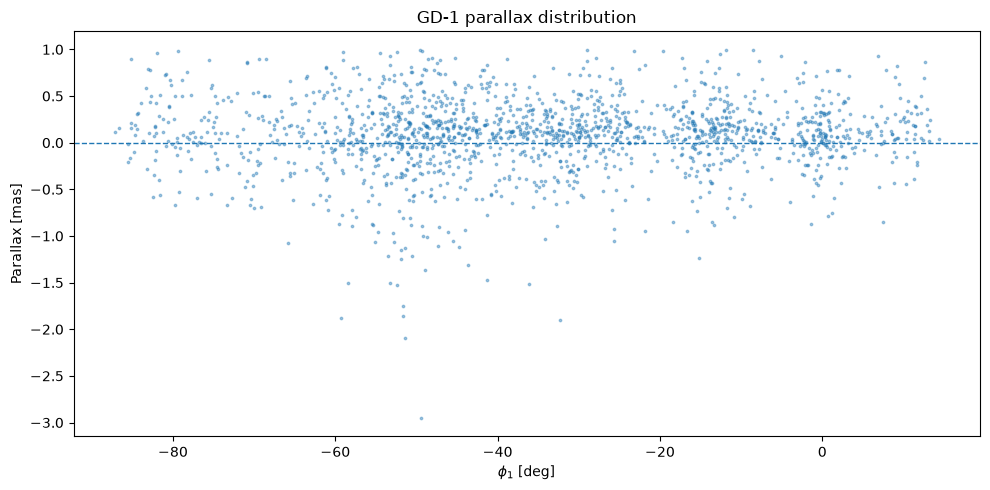

In [119]:
plt.figure(figsize=(10, 5))

plt.scatter(
    phi1,
    parallax,
    s=3,
    alpha=0.4
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel(r"$\phi_1$ [deg]")
plt.ylabel(r"Parallax [mas]")
plt.title("GD-1 parallax distribution")

plt.tight_layout()
plt.show()

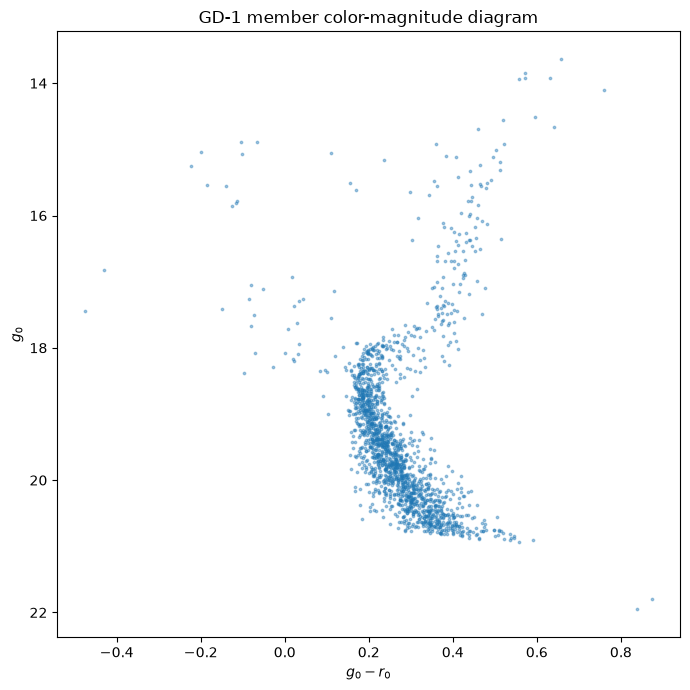

In [120]:
# GD-1 member color-magnitude diagram

g0 = np.asarray(members["g0"])
r0 = np.asarray(members["r0"])

color_gr = g0 - r0

plt.figure(figsize=(7, 7))

plt.scatter(
    color_gr,
    g0,
    s=3,
    alpha=0.4
)

plt.gca().invert_yaxis()

plt.xlabel(r"$g_0-r_0$")
plt.ylabel(r"$g_0$")
plt.title("GD-1 member color-magnitude diagram")

plt.tight_layout()
plt.show()

## De Boer distance values

In [121]:
# ============================================================
# GD-1 distance track: de Boer et al. (2020)
# ============================================================

phi1_deboer = np.array([
    -85, -75, -65, -55, -45, -35,
    -25, -15,  -5,   5,  15,  25
], dtype=float)

distance_deboer = np.array([
     8.84,  8.57,  7.14,  7.63,  7.55,  7.34,
     7.90,  8.63,  9.10, 11.07, 12.06, 15.73
], dtype=float)

distance_err_deboer = np.array([
    0.07, 0.12, 0.16, 0.07, 0.05, 0.06,
    0.06, 0.11, 0.11, 0.08, 0.08, 0.05
], dtype=float)

print("de Boer et al. (2020) distance measurements")
print(f"Number of points : {len(phi1_deboer)}")
print(f"phi1 range       : {phi1_deboer.min():.1f} to {phi1_deboer.max():.1f} deg")
print(f"distance range   : {distance_deboer.min():.2f} to {distance_deboer.max():.2f} kpc")

de Boer et al. (2020) distance measurements
Number of points : 12
phi1 range       : -85.0 to 25.0 deg
distance range   : 7.14 to 15.73 kpc


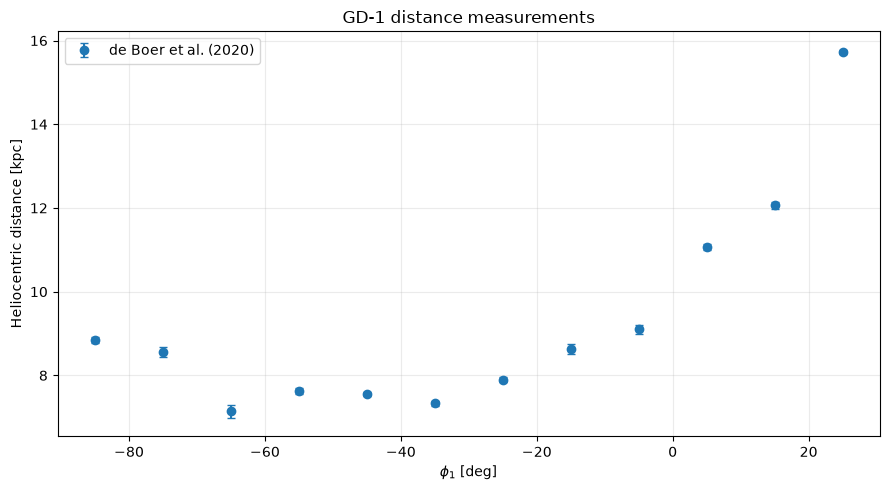

In [122]:
plt.figure(figsize=(9, 5))

plt.errorbar(
    phi1_deboer,
    distance_deboer,
    yerr=distance_err_deboer,
    fmt="o",
    capsize=3,
    label="de Boer et al. (2020)"
)

plt.xlabel(r"$\phi_1$ [deg]")
plt.ylabel(r"Heliocentric distance [kpc]")
plt.title("GD-1 distance measurements")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

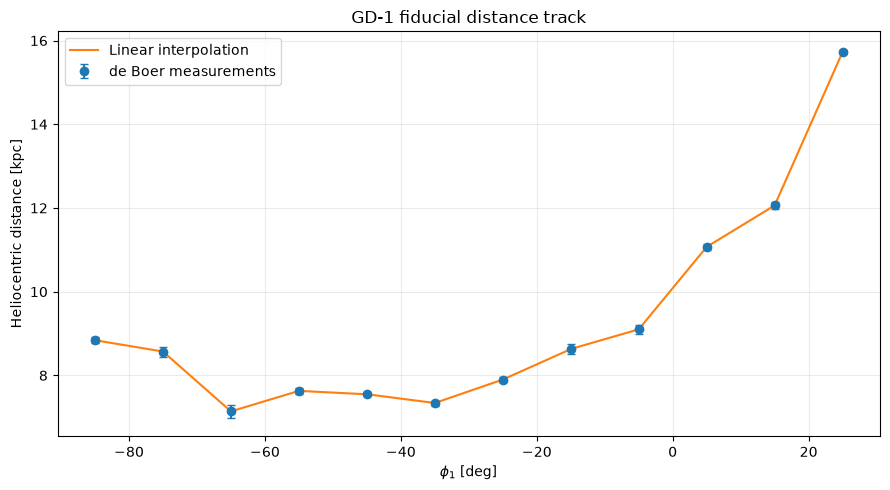

In [123]:
from scipy.interpolate import interp1d

distance_deboer_interp = interp1d(
    phi1_deboer,
    distance_deboer,
    kind="linear",
    bounds_error=True
)

phi1_grid = np.linspace(
    phi1_deboer.min(),
    phi1_deboer.max(),
    500
)

distance_grid = distance_deboer_interp(phi1_grid)

plt.figure(figsize=(9, 5))

plt.errorbar(
    phi1_deboer,
    distance_deboer,
    yerr=distance_err_deboer,
    fmt="o",
    capsize=3,
    label="de Boer measurements"
)

plt.plot(
    phi1_grid,
    distance_grid,
    label="Linear interpolation"
)

plt.xlabel(r"$\phi_1$ [deg]")
plt.ylabel(r"Heliocentric distance [kpc]")
plt.title("GD-1 fiducial distance track")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [124]:
mask_deboer_fid = phi1_deboer <= 15

phi1_deboer_fid = phi1_deboer[mask_deboer_fid]
distance_deboer_fid = distance_deboer[mask_deboer_fid]
distance_err_deboer_fid = distance_err_deboer[mask_deboer_fid]

print("Fiducial de Boer range:")
print(f"phi1: {phi1_deboer_fid.min():.1f} to {phi1_deboer_fid.max():.1f} deg")
print(f"N   : {len(phi1_deboer_fid)}")

Fiducial de Boer range:
phi1: -85.0 to 15.0 deg
N   : 11


## GALSTREAMS

In [125]:
mws = MWStreams()

gd1_names = [
    name for name in mws.summary["Name"]
    if "GD-1" in str(name)
]

gd1_names

Initializing galstreams library from master_log... 


['GD-1', 'GD-1', 'GD-1']

In [126]:
# Inspect the GD-1 entries in the galstreams summary

gd1_rows = mws.summary[
    mws.summary["Name"].astype(str) == "GD-1"
]

print(gd1_rows)
print("\nColumns:")
print(mws.summary.columns.tolist())

          Imp     On  TrackName  Name        TrackRefs  \
TrackName                                                
GD-1-I21   st   True   GD-1-I21  GD-1        ibata2021   
GD-1-I24   st  False   GD-1-I24  GD-1        ibata2024   
GD-1-PB18  st  False  GD-1-PB18  GD-1  pricewhelan2018   

                                  TrackRefsLatex Notes  from-Members  \
TrackName                                                              
GD-1-I21                               Ibata2021     -             1   
GD-1-I24                               Ibata2024     -             1   
GD-1-PB18  PriceWhelanBonaca2018_gd1,Koposov2010     -             1   

           width_phi2 width_phi2_Ref  ...  distance_mid    ra_pole   dec_pole  \
TrackName                             ...                                       
GD-1-I21         0.65   from-Members  ...      7.620637  34.785780  29.131333   
GD-1-I24         0.54   from-Members  ...      1.000000  35.121277  28.826755   
GD-1-PB18        0.67   

In [127]:
# Print each GD-1 row individually so we can identify the literature source

for i, row in gd1_rows.iterrows():
    print("\n" + "=" * 70)
    print("ROW INDEX:", i)
    for col in mws.summary.columns:
        print(f"{col}: {row[col]}")


ROW INDEX: GD-1-I21
Imp: st
On: True
TrackName: GD-1-I21
Name: GD-1
TrackRefs: ibata2021
TrackRefsLatex: Ibata2021
Notes: -
from-Members: 1
width_phi2: 0.65
width_phi2_Ref: from-Members
width_pm_phi1_cosphi2: 0.46
width_pm_phi1_cosphi2_Ref: from-Members
width_pm_phi2: 0.38
width_pm_phi2_Ref: from-Members
total_v_sigma: -1.0
total_v_sigma_Ref: from-Members
Lv_stream: 0.0
L_Ref: --------
width_comment: apparent
length: 102.52109985505322
ra_o: 123.2755445128934
dec_o: -10.088678886107271
distance_o: 9.199134134222826
ra_f: 219.91332538819165
dec_f: 57.91071902630444
distance_f: 11.684442740062588
ra_mid: 148.14590426569234
dec_mid: 35.43732836633419
distance_mid: 7.620636575836133
ra_pole: 34.78577977781821
dec_pole: 29.131333319097116
InfoFlags: 1111
has_empirical_track: 1
has_D: 1
has_pm: 1
has_vrad: 1
DiscoveryRefs: Grillmair2006_gd1
ID: 31

ROW INDEX: GD-1-I24
Imp: st
On: False
TrackName: GD-1-I24
Name: GD-1
TrackRefs: ibata2024
TrackRefsLatex: Ibata2024
Notes: -
from-Members: 1
wid

In [128]:
mws_all = MWStreams(implement_Off=True)

print(mws_all.get_track_names_for_stream("GD-1"))

Initializing galstreams library from master_log... 
['GD-1-I21', 'GD-1-I24', 'GD-1-PB18']


In [129]:
gd1_i21 = mws_all["GD-1-I21"]
gd1_i24 = mws_all["GD-1-I24"]
gd1_pb18 = mws_all["GD-1-PB18"]

print(type(gd1_i21))
print(type(gd1_i24))
print(type(gd1_pb18))

<class 'galstreams.core.Track6D'>
<class 'galstreams.core.Track6D'>
<class 'galstreams.core.Track6D'>


In [130]:
print("I21 attributes:")
print(gd1_i21.__dict__.keys())

print("\nPB18 attributes:")
print(gd1_pb18.__dict__.keys())

I21 attributes:
dict_keys(['track_name', 'stream_name', 'stream_sname', 'stream_shortname', 'ref', 'ref_discovery', 'track', 'InfoFlags', 'end_points', 'mid_point', 'mid_pole', 'track_width', 'stream_frame', 'poly_sc', 'angular_momentum_helio', 'pole_track_helio', 'pole_track_gsr', 'mid_pole_gsr', 'length', 'ID'])

PB18 attributes:
dict_keys(['track_name', 'stream_name', 'stream_sname', 'stream_shortname', 'ref', 'ref_discovery', 'track', 'InfoFlags', 'end_points', 'mid_point', 'mid_pole', 'track_width', 'stream_frame', 'poly_sc', 'angular_momentum_helio', 'pole_track_helio', 'pole_track_gsr', 'mid_pole_gsr', 'length', 'ID'])


In [131]:
print("I21:")
print(gd1_i21)

print("\nPB18:")
print(gd1_pb18)

I21:

PB18:


In [132]:
print("I21 track type:")
print(type(gd1_i21.track))

print("\nI21 track:")
print(gd1_i21.track)

print("\nI21 frame:")
print(gd1_i21.track.frame)

I21 track type:
<class 'astropy.coordinates.sky_coordinate.SkyCoord'>

I21 track:
<SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, kpc)
    [(123.27554451, -10.08867889,  9.19913413),
     (123.27915026, -10.07921446,  9.19864732),
     (123.2827562 , -10.06975018,  9.1981605 ), ...,
     (219.87607135,  57.91437012, 11.68099538),
     (219.89469935,  57.91254606, 11.68271884),
     (219.91332539,  57.91071903, 11.68444274)]
 (pm_ra_cosdec, pm_dec, radial_velocity) in (mas / yr, mas / yr, km / s)
    [(-0.95430401, -7.40892771,  249.16278838),
     (-0.95520505, -7.41182271,  249.12918378),
     (-0.95610599, -7.41471691,  249.09557242), ...,
     (-6.45077431, -1.33725963, -245.39650904),
     (-6.44890581, -1.3354567 , -245.44014588),
     (-6.44703651, -1.33365527, -245.48377792)]>

I21 frame:
<ICRS Coordinate: (ra, dec, distance) in (deg, deg, kpc)
    [(123.27554451, -10.08867889,  9.19913413),
     (123.27915026, -10.07921446,  9.19864732),
     (123.2827562 , -10.06975018,  9

In [133]:
print("PB18 track type:")
print(type(gd1_pb18.track))

print("\nPB18 track:")
print(gd1_pb18.track)

print("\nPB18 frame:")
print(gd1_pb18.track.frame)

PB18 track type:
<class 'astropy.coordinates.sky_coordinate.SkyCoord'>

PB18 track:
<SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, kpc)
    [(124.0646377 , -7.97077298,  5.50834758),
     (124.06831761, -7.96136413,  5.50884762),
     (124.07199789, -7.95195551,  5.50934766), ...,
     (219.52460701, 58.20827053, 10.49774106),
     (219.54341787, 58.20676868, 10.4982411 ),
     (219.56222712, 58.20526418, 10.49874114)]
 (pm_ra_cosdec, pm_dec, radial_velocity) in (mas / yr, mas / yr, km / s)
    [(-2.38349819, -7.85648379, -1.92961458e-09),
     (-2.38267622, -7.8585463 , -1.92745886e-09),
     (-2.38185575, -7.86060859, -1.92525683e-09), ...,
     (-8.44602006, -1.37080203,  1.29612069e-08),
     (-8.44599945, -1.36848967,  1.29622174e-08),
     (-8.44597898, -1.36617805,  1.29631479e-08)]>

PB18 frame:
<ICRS Coordinate: (ra, dec, distance) in (deg, deg, kpc)
    [(124.0646377 , -7.97077298,  5.50834758),
     (124.06831761, -7.96136413,  5.50884762),
     (124.07199789, -7.951955

In [134]:
print("I21 shape:", gd1_i21.track.shape)
print("PB18 shape:", gd1_pb18.track.shape)

I21 shape: (10209,)
PB18 shape: (9981,)


In [135]:
print("I21 coordinate components:")
print(gd1_i21.track.data)

print("\nI21 available attributes:")
print(gd1_i21.track.data.components)

I21 coordinate components:
[(123.27554451, -10.08867889,  9.19913413),
 (123.27915026, -10.07921446,  9.19864732),
 (123.2827562 , -10.06975018,  9.1981605 ), ...,
 (219.87607135,  57.91437012, 11.68099538),
 (219.89469935,  57.91254606, 11.68271884),
 (219.91332539,  57.91071903, 11.68444274)] (deg, deg, kpc)

I21 available attributes:
('lon', 'lat', 'distance')


In [136]:
print("PB18 coordinate components:")
print(gd1_pb18.track.data)

print("\nPB18 available attributes:")
print(gd1_pb18.track.data.components)

PB18 coordinate components:
[(124.0646377 , -7.97077298,  5.50834758),
 (124.06831761, -7.96136413,  5.50884762),
 (124.07199789, -7.95195551,  5.50934766), ...,
 (219.52460701, 58.20827053, 10.49774106),
 (219.54341787, 58.20676868, 10.4982411 ),
 (219.56222712, 58.20526418, 10.49874114)] (deg, deg, kpc)

PB18 available attributes:
('lon', 'lat', 'distance')


In [137]:
print(gd1_i21.track)

print(gd1_i21.track.info)

<SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, kpc)
    [(123.27554451, -10.08867889,  9.19913413),
     (123.27915026, -10.07921446,  9.19864732),
     (123.2827562 , -10.06975018,  9.1981605 ), ...,
     (219.87607135,  57.91437012, 11.68099538),
     (219.89469935,  57.91254606, 11.68271884),
     (219.91332539,  57.91071903, 11.68444274)]
 (pm_ra_cosdec, pm_dec, radial_velocity) in (mas / yr, mas / yr, km / s)
    [(-0.95430401, -7.40892771,  249.16278838),
     (-0.95520505, -7.41182271,  249.12918378),
     (-0.95610599, -7.41471691,  249.09557242), ...,
     (-6.45077431, -1.33725963, -245.39650904),
     (-6.44890581, -1.3354567 , -245.44014588),
     (-6.44703651, -1.33365527, -245.48377792)]>
dtype = object
unit = deg,deg,kpc
class = SkyCoord
n_bad = 0
length = 10209



In [138]:
print(gd1_pb18.track)

print(gd1_pb18.track.info)

<SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, kpc)
    [(124.0646377 , -7.97077298,  5.50834758),
     (124.06831761, -7.96136413,  5.50884762),
     (124.07199789, -7.95195551,  5.50934766), ...,
     (219.52460701, 58.20827053, 10.49774106),
     (219.54341787, 58.20676868, 10.4982411 ),
     (219.56222712, 58.20526418, 10.49874114)]
 (pm_ra_cosdec, pm_dec, radial_velocity) in (mas / yr, mas / yr, km / s)
    [(-2.38349819, -7.85648379, -1.92961458e-09),
     (-2.38267622, -7.8585463 , -1.92745886e-09),
     (-2.38185575, -7.86060859, -1.92525683e-09), ...,
     (-8.44602006, -1.37080203,  1.29612069e-08),
     (-8.44599945, -1.36848967,  1.29622174e-08),
     (-8.44597898, -1.36617805,  1.29631479e-08)]>
dtype = object
unit = deg,deg,kpc
class = SkyCoord
n_bad = 0
length = 9981



In [139]:
# Transform the empirical tracks into their native GD-1 stream frames
i21_gd1 = gd1_i21.track.transform_to(gd1_i21.stream_frame)
pb18_gd1 = gd1_pb18.track.transform_to(gd1_pb18.stream_frame)

print("I21 frame:")
print(i21_gd1)
print("\nPB18 frame:")
print(pb18_gd1)

print("\nI21 components:", i21_gd1.data.components)
print("PB18 components:", pb18_gd1.data.components)

I21 frame:
<SkyCoord (GreatCircleICRSFrame: pole=<ICRS Coordinate: (ra, dec) in deg
    (34.78577978, 29.13133332)>, origin=<ICRS Coordinate: (ra, dec) in deg
    (148.14590427, 35.43072214)>, priority=origin): (phi1, phi2, distance) in (deg, deg, kpc)
    [(-51.13389982, -3.58965841,  9.19913413),
     (-51.12388038, -3.58818108,  9.19864732),
     (-51.11386095, -3.58670409,  9.1981605 ), ...,
     ( 51.12445608, -2.84931405, 11.68099538),
     ( 51.13447552, -2.85036334, 11.68271884),
     ( 51.14449495, -2.85141279, 11.68444274)]
 (pm_phi1_cosphi2, pm_phi2, radial_velocity) in (mas / yr, mas / yr, km / s)
    [(-6.9443532 , -2.75297379,  249.16278838),
     (-6.94732263, -2.75358691,  249.12918378),
     (-6.9502913 , -2.75419976,  249.09557242), ...,
     (-6.3275544 , -1.83379602, -245.39650904),
     (-6.32531066, -1.83365095, -245.44014588),
     (-6.32306666, -1.83350599, -245.48377792)]>

PB18 frame:
<SkyCoord (GreatCircleICRSFrame: pole=<ICRS Coordinate: (ra, dec) in deg
   

In [140]:
# Convert the transformed coordinates to spherical representation
i21_sph = i21_gd1.represent_as("spherical")
pb18_sph = pb18_gd1.represent_as("spherical")

print("I21 spherical:", i21_sph)
print("PB18 spherical:", pb18_sph)

I21 spherical: [(-0.89245491, -0.06265136,  9.19913413),
 (-0.89228004, -0.06262557,  9.19864732),
 (-0.89210517, -0.0625998 ,  9.1981605 ), ...,
 ( 0.89229009, -0.04972991, 11.68099538),
 ( 0.89246496, -0.04974823, 11.68271884),
 ( 0.89263983, -0.04976654, 11.68444274)] (rad, rad, kpc)
PB18 spherical: [(-1.57229307, -0.06079559,  5.50834758),
 (-1.57211852, -0.06076993,  5.50884762),
 (-1.57194397, -0.06074428,  5.50934766), ...,
 ( 0.16933381, -0.03423918, 10.49774106),
 ( 0.16950836, -0.03425239, 10.4982411 ),
 ( 0.1696829 , -0.03426559, 10.49874114)] (rad, rad, kpc)


In [141]:
phi1_i21 = i21_sph.lon.to_value("deg")
phi2_i21 = i21_sph.lat.to_value("deg")
dist_i21 = i21_sph.distance.to_value("kpc")

phi1_pb18 = pb18_sph.lon.to_value("deg")
phi2_pb18 = pb18_sph.lat.to_value("deg")
dist_pb18 = pb18_sph.distance.to_value("kpc")

print("I21 phi1 range:", phi1_i21.min(), phi1_i21.max())
print("I21 phi2 range:", phi2_i21.min(), phi2_i21.max())
print("I21 distance range:", dist_i21.min(), dist_i21.max())

print()

print("PB18 phi1 range:", phi1_pb18.min(), phi1_pb18.max())
print("PB18 phi2 range:", phi2_pb18.min(), phi2_pb18.max())
print("PB18 distance range:", dist_pb18.min(), dist_pb18.max())

I21 phi1 range: -51.133899818824794 51.14449495431315
I21 phi2 range: -3.589658405740234 0.0039513907422645735
I21 distance range: 7.613300902833091 11.684442740062588

PB18 phi1 range: -90.08575688155379 9.722114301440302
PB18 phi2 range: -3.483330816553855 0.3361768954530513
PB18 distance range: 5.508347580561653 10.498741139672246


### Comparision of distance tracks

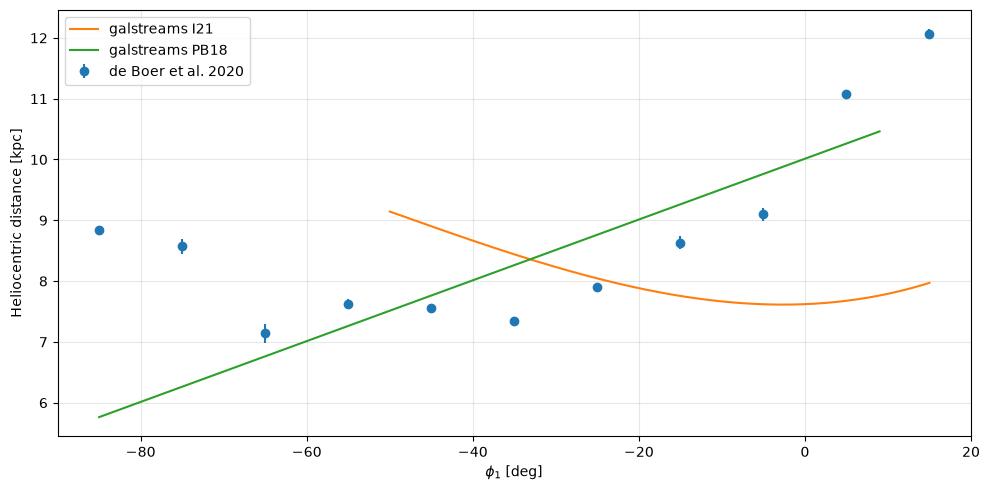

In [142]:
import numpy as np
import matplotlib.pyplot as plt

# de Boer 2020
phi1_deboer = np.array([
    -85, -75, -65, -55, -45, -35,
    -25, -15, -5, 5, 15, 25
], dtype=float)

distance_deboer = np.array([
    8.84, 8.57, 7.14, 7.63, 7.55, 7.34,
    7.90, 8.63, 9.10, 11.07, 12.06, 15.73
], dtype=float)

distance_deboer_err = np.array([
    0.07, 0.12, 0.16, 0.07, 0.05, 0.06,
    0.06, 0.11, 0.11, 0.08, 0.08, 0.05
], dtype=float)


# Restrict comparison to the well-supported de Boer range
mask_deboer = (phi1_deboer >= -85) & (phi1_deboer <= 15)

phi_deb = phi1_deboer[mask_deboer]
d_deb = distance_deboer[mask_deboer]
e_deb = distance_deboer_err[mask_deboer]


# I21
mask_i21 = (phi1_i21 >= -50) & (phi1_i21 <= 15)

phi_i21 = phi1_i21[mask_i21]
d_i21 = dist_i21[mask_i21]


# PB18
mask_pb18 = (phi1_pb18 >= -85) & (phi1_pb18 <= 9)

phi_pb18 = phi1_pb18[mask_pb18]
d_pb18 = dist_pb18[mask_pb18]


plt.figure(figsize=(10, 5))

plt.errorbar(
    phi_deb,
    d_deb,
    yerr=e_deb,
    fmt="o",
    label="de Boer et al. 2020"
)

plt.plot(
    phi_i21,
    d_i21,
    label="galstreams I21"
)

plt.plot(
    phi_pb18,
    d_pb18,
    label="galstreams PB18"
)

plt.xlabel(r"$\phi_1$ [deg]")
plt.ylabel("Heliocentric distance [kpc]")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [143]:
from scipy.interpolate import interp1d

# Interpolate the empirical tracks onto de Boer's positions
i21_interp = interp1d(
    phi_i21,
    d_i21,
    bounds_error=False,
    fill_value=np.nan
)

pb18_interp = interp1d(
    phi_pb18,
    d_pb18,
    bounds_error=False,
    fill_value=np.nan
)

d_i21_at_deb = i21_interp(phi_deb)
d_pb18_at_deb = pb18_interp(phi_deb)

delta_i21 = d_i21_at_deb - d_deb
delta_pb18 = d_pb18_at_deb - d_deb

print("phi1    deBoer    I21      ΔI21      PB18     ΔPB18")
print("-" * 65)

for p, d, di, dpi, dp, dpp in zip(
    phi_deb,
    d_deb,
    d_i21_at_deb,
    delta_i21,
    d_pb18_at_deb,
    delta_pb18
):
    print(
        f"{p:5.0f}  "
        f"{d:7.2f}  "
        f"{di:7.2f}  "
        f"{dpi:8.2f}  "
        f"{dp:7.2f}  "
        f"{dpp:8.2f}"
    )

phi1    deBoer    I21      ΔI21      PB18     ΔPB18
-----------------------------------------------------------------
  -85     8.84      nan       nan      nan       nan
  -75     8.57      nan       nan     6.26     -2.31
  -65     7.14      nan       nan     6.76     -0.38
  -55     7.63      nan       nan     7.26     -0.37
  -45     7.55     8.90      1.35     7.76      0.21
  -35     7.34     8.44      1.10     8.26      0.92
  -25     7.90     8.04      0.14     8.76      0.86
  -15     8.63     7.76     -0.87     9.26      0.63
   -5     9.10     7.62     -1.48     9.76      0.66
    5    11.07     7.68     -3.39    10.26     -0.81
   15    12.06      nan       nan      nan       nan


In [144]:
# Residuals relative to de Boer
valid_i21 = np.isfinite(d_i21_at_deb)
valid_pb18 = np.isfinite(d_pb18_at_deb)

print("I21 vs de Boer")
print("----------------")
print("N =", valid_i21.sum())
print("Mean Δd =", np.nanmean(delta_i21), "kpc")
print("Median Δd =", np.nanmedian(delta_i21), "kpc")
print("RMS Δd =", np.sqrt(np.nanmean(delta_i21**2)), "kpc")
print("Max |Δd| =", np.nanmax(np.abs(delta_i21)), "kpc")

print()

print("PB18 vs de Boer")
print("----------------")
print("N =", valid_pb18.sum())
print("Mean Δd =", np.nanmean(delta_pb18), "kpc")
print("Median Δd =", np.nanmedian(delta_pb18), "kpc")
print("RMS Δd =", np.sqrt(np.nanmean(delta_pb18**2)), "kpc")
print("Max |Δd| =", np.nanmax(np.abs(delta_pb18)), "kpc")

I21 vs de Boer
----------------
N = 6
Mean Δd = -0.5255357680761876 kpc
Median Δd = -0.365290029210267 kpc
RMS Δd = 1.709511561017486 kpc
Max |Δd| = 3.3937065435912075 kpc

PB18 vs de Boer
----------------
N = 9
Mean Δd = -0.062920131014927 kpc
Median Δd = 0.21263542451619166 kpc
RMS Δd = 0.985057962629959 kpc
Max |Δd| = 2.3073645754004524 kpc


In [145]:
sigma_i21 = delta_i21 / e_deb
sigma_pb18 = delta_pb18 / e_deb

print("I21 discrepancy in de Boer sigma units:")
print(sigma_i21)

print()

print("PB18 discrepancy in de Boer sigma units:")
print(sigma_pb18)

I21 discrepancy in de Boer sigma units:
[         nan          nan          nan          nan  27.04041321
  18.33665109   2.39600517  -7.9485488  -13.46497938 -42.42133179
          nan]

PB18 discrepancy in de Boer sigma units:
[         nan -19.22803813  -2.3585286   -5.24806536   4.25270849
  15.37725708  14.37725708   5.75123113   6.0239584  -10.09205719
          nan]


The disagreement between published distance prescriptions is much larger than the quoted statistical uncertainties of the de Boer measurements, demonstrating that distance-track/model systematics dominate over the formal pointwise statistical errors in some parts of GD-1.

High-quality region from -60 to 0

In [146]:
import numpy as np
import matplotlib.pyplot as plt

phi1 = np.asarray(members["phi1"])
phi2 = np.asarray(members["phi2"])
pm1 = np.asarray(members["pm1"])
pm2 = np.asarray(members["pm2"])

has_rv = np.asarray(members["e_rv"]) < 10000

# Define broad stream region
core = (phi1 >= -60) & (phi1 <= 0)

print("All selected members:", len(members))
print("Core region members:", core.sum())
print("Core region with RV:", np.sum(core & has_rv))

print("\nCore phi1 range:")
print(phi1[core].min(), phi1[core].max())

print("\nCore phi2:")
print("median =", np.nanmedian(phi2[core]))
print("std    =", np.nanstd(phi2[core]))

print("\nCore PM1:")
print("median =", np.nanmedian(pm1[core]))
print("std    =", np.nanstd(pm1[core]))

print("\nCore PM2:")
print("median =", np.nanmedian(pm2[core]))
print("std    =", np.nanstd(pm2[core]))

All selected members: 1689
Core region members: 1311
Core region with RV: 314

Core phi1 range:
-59.99775540325197 -0.03478519974680694

Core phi2:
median = -0.07190549019680445
std    = 0.5615625504828464

Core PM1:
median = -12.846579052040637
std    = 1.4987701676440512

Core PM2:
median = -3.066187953305395
std    = 0.6477455573250784


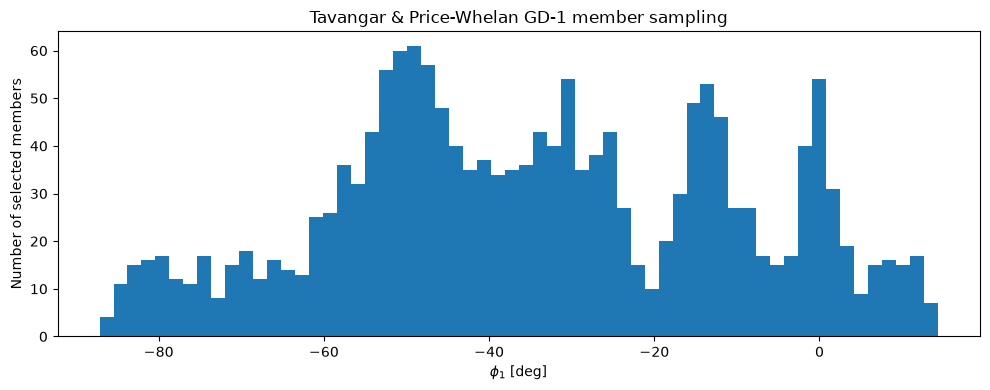

In [147]:
plt.figure(figsize=(10, 4))

plt.hist(
    phi1,
    bins=60
)

plt.xlabel(r"$\phi_1$ [deg]")
plt.ylabel("Number of selected members")
plt.title("Tavangar & Price-Whelan GD-1 member sampling")

plt.tight_layout()
plt.show()

### observed phase-space tracks

In [148]:
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Core GD-1 sample
# ------------------------------------------------------------

phi1 = np.asarray(members["phi1"], dtype=float)
phi2 = np.asarray(members["phi2"], dtype=float)
pm1  = np.asarray(members["pm1"], dtype=float)
pm2  = np.asarray(members["pm2"], dtype=float)
rv   = np.asarray(members["rv"], dtype=float)
e_rv = np.asarray(members["e_rv"], dtype=float)

has_rv = e_rv < 10000

core = (phi1 >= -60) & (phi1 <= 0)

# 2-degree bins
bin_edges = np.arange(-60, 0.0001, 2.0)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])


def robust_mad(x):
    """Gaussian-equivalent robust scatter."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return np.nan

    med = np.median(x)
    return 1.4826 * np.median(np.abs(x - med))


rows = []

for lo, hi, center in zip(
    bin_edges[:-1],
    bin_edges[1:],
    bin_centers
):

    sel = core & (phi1 >= lo) & (phi1 < hi)

    # RV is treated separately because many entries are missing
    sel_rv = sel & has_rv

    rows.append({
        "phi1": center,

        "N": np.sum(sel),

        "phi2_med": np.median(phi2[sel]) if np.any(sel) else np.nan,
        "phi2_mad": robust_mad(phi2[sel]),

        "pm1_med": np.median(pm1[sel]) if np.any(sel) else np.nan,
        "pm1_mad": robust_mad(pm1[sel]),

        "pm2_med": np.median(pm2[sel]) if np.any(sel) else np.nan,
        "pm2_mad": robust_mad(pm2[sel]),

        "N_rv": np.sum(sel_rv),

        "rv_med": np.median(rv[sel_rv]) if np.any(sel_rv) else np.nan,
        "rv_mad": robust_mad(rv[sel_rv]),
    })


gd1_profiles = pd.DataFrame(rows)

print(gd1_profiles.to_string(index=False))

 phi1  N  phi2_med  phi2_mad    pm1_med  pm1_mad   pm2_med  pm2_mad  N_rv      rv_med    rv_mad
-59.0 36 -0.691892  0.211865 -12.759150 0.266061 -3.675428 0.320396     2   85.387799 24.724855
-57.0 35 -0.329925  0.325346 -13.031629 0.261716 -3.409721 0.542376    11   96.920886 22.577904
-55.0 42 -0.299066  0.242074 -13.054088 0.273257 -3.565765 0.299902     3   92.298266  2.564472
-53.0 59 -0.218379  0.284091 -13.196227 0.320912 -3.619538 0.575525     1   62.247969  0.000000
-51.0 78 -0.125471  0.322743 -13.353066 0.280896 -3.450793 0.456057     5   52.555439  8.814775
-49.0 69  0.069153  0.310245 -13.486903 0.232034 -3.523425 0.349135    15   41.284592 14.526199
-47.0 66  0.029331  0.251926 -13.364689 0.260892 -3.520883 0.448314    20   24.765855  5.882882
-45.0 54  0.087240  0.314440 -13.395667 0.340671 -3.399267 0.324136    12   18.406722  9.338930
-43.0 46  0.138233  0.392577 -13.409546 0.207690 -3.432629 0.188879     5    9.559751  3.461361
-41.0 39  0.180532  0.383125 -13.284070 

ϕ2

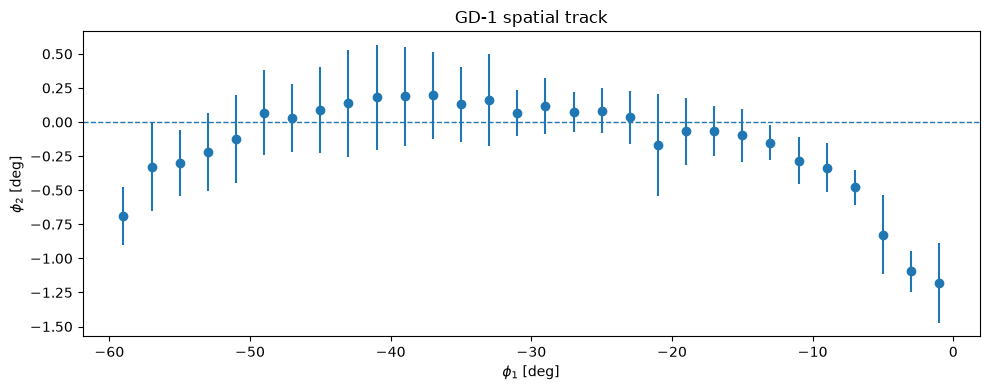

In [149]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.errorbar(
    gd1_profiles["phi1"],
    gd1_profiles["phi2_med"],
    yerr=gd1_profiles["phi2_mad"],
    fmt="o"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel(r"$\phi_1$ [deg]")
plt.ylabel(r"$\phi_2$ [deg]")
plt.title("GD-1 spatial track")


plt.tight_layout()
plt.show()

Proper motion

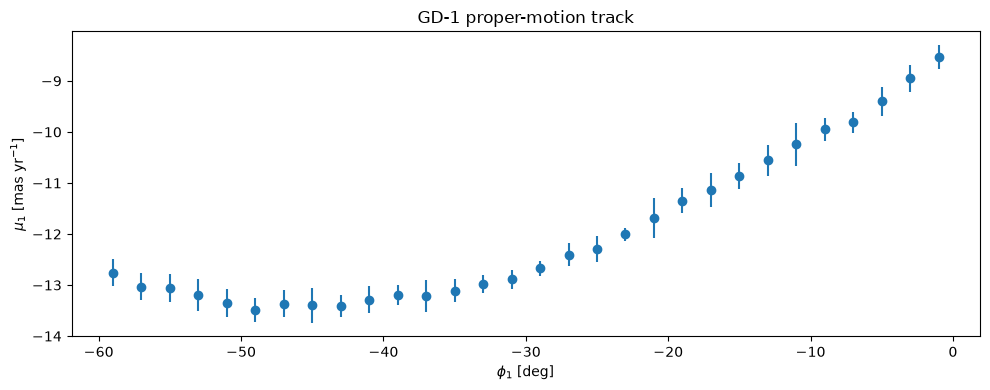

In [150]:
plt.figure(figsize=(10, 4))

plt.errorbar(
    gd1_profiles["phi1"],
    gd1_profiles["pm1_med"],
    yerr=gd1_profiles["pm1_mad"],
    fmt="o",
    label=r"$\mu_1$"
)

plt.xlabel(r"$\phi_1$ [deg]")
plt.ylabel(r"$\mu_1$ [mas yr$^{-1}$]")
plt.title("GD-1 proper-motion track")

plt.tight_layout()
plt.show()

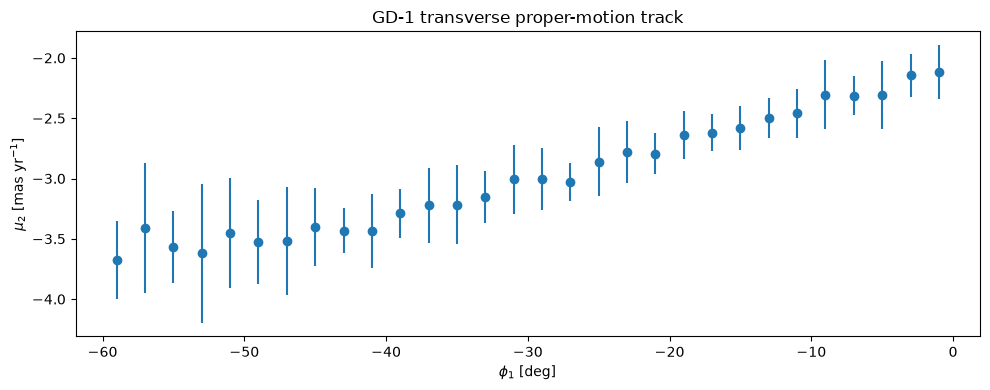

In [151]:
plt.figure(figsize=(10, 4))

plt.errorbar(
    gd1_profiles["phi1"],
    gd1_profiles["pm2_med"],
    yerr=gd1_profiles["pm2_mad"],
    fmt="o"
)

plt.xlabel(r"$\phi_1$ [deg]")
plt.ylabel(r"$\mu_2$ [mas yr$^{-1}$]")
plt.title("GD-1 transverse proper-motion track")

plt.tight_layout()
plt.show()

RV profile

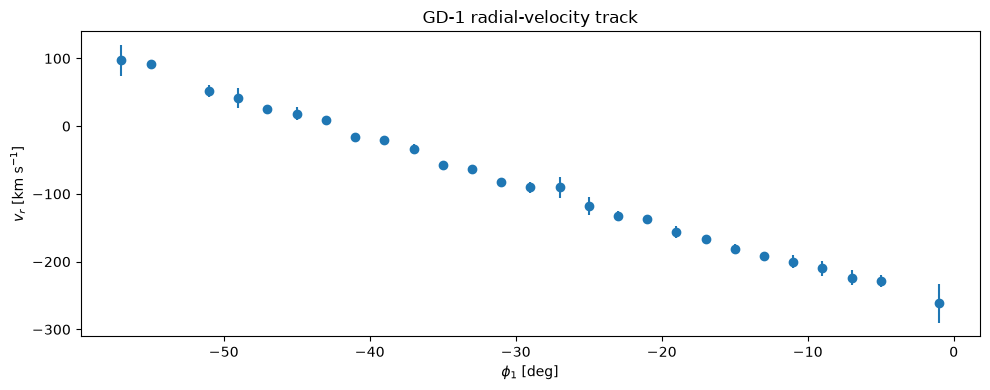

In [152]:
plt.figure(figsize=(10, 4))

valid = gd1_profiles["N_rv"] >= 3

plt.errorbar(
    gd1_profiles.loc[valid, "phi1"],
    gd1_profiles.loc[valid, "rv_med"],
    yerr=gd1_profiles.loc[valid, "rv_mad"],
    fmt="o"
)

plt.xlabel(r"$\phi_1$ [deg]")
plt.ylabel(r"$v_r$ [km s$^{-1}$]")
plt.title("GD-1 radial-velocity track")

plt.tight_layout()
plt.show()

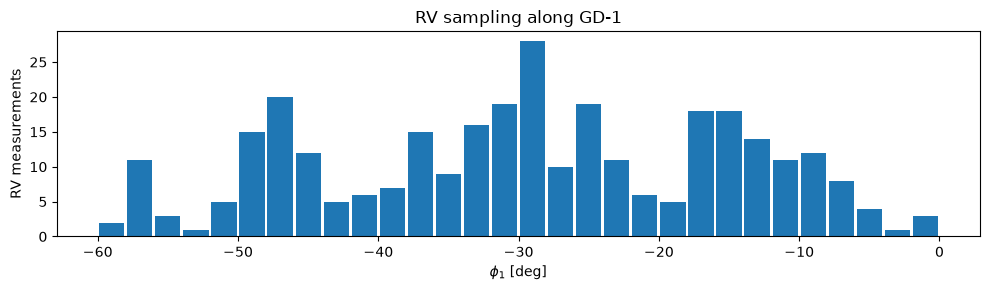

In [153]:
plt.figure(figsize=(10, 3))

plt.bar(
    gd1_profiles["phi1"],
    gd1_profiles["N_rv"],
    width=1.8
)

plt.xlabel(r"$\phi_1$ [deg]")
plt.ylabel("RV measurements")
plt.title("RV sampling along GD-1")

plt.tight_layout()
plt.show()

bootstrap the centroids

In [154]:
def bootstrap_median(x, n_boot=1000, rng=None):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 2:
        return np.nan, np.nan

    rng = np.random.default_rng(rng)

    boot = np.empty(n_boot)

    for i in range(n_boot):
        sample = rng.choice(x, size=len(x), replace=True)
        boot[i] = np.median(sample)

    med = np.median(x)
    lo, hi = np.percentile(boot, [16, 84])

    return med, 0.5 * (hi - lo)

In [155]:
rows = []

for lo, hi, center in zip(
    bin_edges[:-1],
    bin_edges[1:],
    bin_centers
):

    sel = core & (phi1 >= lo) & (phi1 < hi)
    sel_rv = sel & has_rv

    row = {
        "phi1": center,
        "N": np.sum(sel),
    }

    # --------------------------------------------------------
    # Spatial track
    # --------------------------------------------------------

    row["phi2_med"], row["phi2_med_err"] = bootstrap_median(
        phi2[sel]
    )

    row["phi2_width"] = robust_mad(phi2[sel])


    # --------------------------------------------------------
    # Proper motion
    # --------------------------------------------------------

    row["pm1_med"], row["pm1_med_err"] = bootstrap_median(
        pm1[sel]
    )

    row["pm1_width"] = robust_mad(pm1[sel])


    row["pm2_med"], row["pm2_med_err"] = bootstrap_median(
        pm2[sel]
    )

    row["pm2_width"] = robust_mad(pm2[sel])


    # --------------------------------------------------------
    # Radial velocity
    # --------------------------------------------------------

    row["N_rv"] = np.sum(sel_rv)

    if row["N_rv"] >= 5:

        row["rv_med"], row["rv_med_err"] = bootstrap_median(
            rv[sel_rv]
        )

        row["rv_width"] = robust_mad(rv[sel_rv])

    else:

        row["rv_med"] = np.nan
        row["rv_med_err"] = np.nan
        row["rv_width"] = np.nan


    rows.append(row)


gd1_profiles = pd.DataFrame(rows)

print(gd1_profiles.to_string(index=False))

 phi1  N  phi2_med  phi2_med_err  phi2_width    pm1_med  pm1_med_err  pm1_width   pm2_med  pm2_med_err  pm2_width  N_rv      rv_med  rv_med_err  rv_width
-59.0 36 -0.691892      0.054500    0.211865 -12.759150     0.046893   0.266061 -3.675428     0.046700   0.320396     2         NaN         NaN       NaN
-57.0 35 -0.329925      0.112045    0.325346 -13.031629     0.058995   0.261716 -3.409721     0.031336   0.542376    11   96.920886    9.369698 22.577904
-55.0 42 -0.299066      0.050034    0.242074 -13.054088     0.062087   0.273257 -3.565765     0.035735   0.299902     3         NaN         NaN       NaN
-53.0 59 -0.218379      0.053437    0.284091 -13.196227     0.042211   0.320912 -3.619538     0.044952   0.575525     1         NaN         NaN       NaN
-51.0 78 -0.125471      0.044371    0.322743 -13.353066     0.043754   0.280896 -3.450793     0.045723   0.456057     5   52.555439    6.009969  8.814775
-49.0 69  0.069153      0.041088    0.310245 -13.486903     0.037665   0.232

Binning stability test

In [156]:
def make_phi2_profile(phi1, phi2, width, lo=-60, hi=0):

    edges = np.arange(lo, hi + width, width)
    centers = 0.5 * (edges[:-1] + edges[1:])

    medians = []
    errors = []
    counts = []

    for left, right in zip(edges[:-1], edges[1:]):

        sel = (
            (phi1 >= left) &
            (phi1 < right)
        )

        x = phi2[sel]

        med, err = bootstrap_median(x, n_boot=1000)

        medians.append(med)
        errors.append(err)
        counts.append(np.sum(sel))

    return (
        np.asarray(centers),
        np.asarray(medians),
        np.asarray(errors),
        np.asarray(counts)
    )

In [157]:
profiles = {}

for width in [1.0, 2.0, 4.0]:

    profiles[width] = make_phi2_profile(
        phi1,
        phi2,
        width
    )

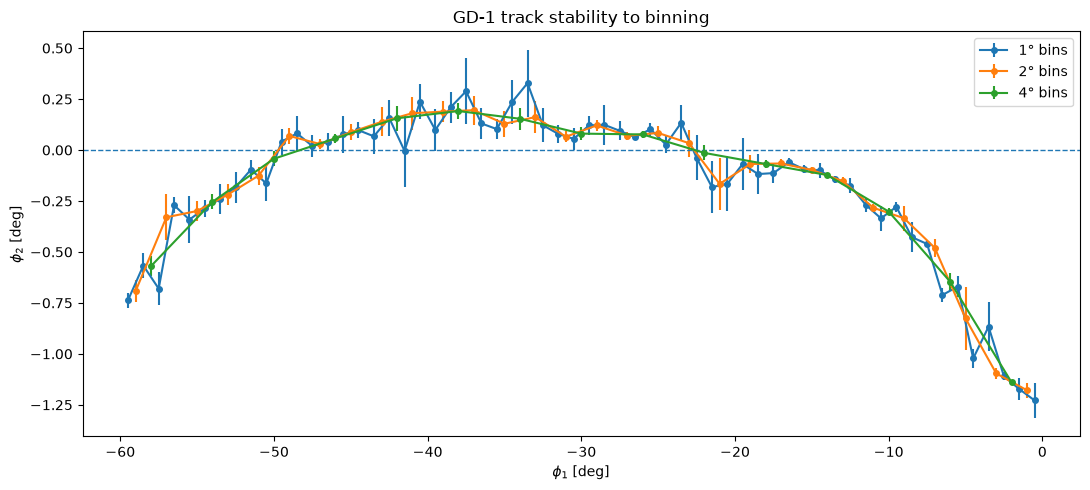

In [158]:
plt.figure(figsize=(11, 5))

for width in [1.0, 2.0, 4.0]:

    x, y, yerr, n = profiles[width]

    plt.errorbar(
        x,
        y,
        yerr=yerr,
        fmt="o-",
        ms=4,
        label=f"{width:.0f}° bins"
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel(r"$\phi_1$ [deg]")
plt.ylabel(r"$\phi_2$ [deg]")
plt.title("GD-1 track stability to binning")

plt.legend()
plt.tight_layout()
plt.show()

Keep

$-60 < \phi_1 < 0$ - as the main dynamical region, but flag

$-50 < \phi_1 < -35$ - as a morphology-complex region rather than masking it.

$\phi_1 \sim -30$

becaaaaaaaaaause 
- I21 track exists
- Tavangar has plenty of members
- RV sampling is good
- Away from most problematic -45deg region

### 6D Observational ANCHOR 



### Previous I21-anchor orbit: discarded

The initial orbit experiment used a 6D point from the galstreams GD-1-I21
track. Although the track object contains velocity information internally,
the galstreams metadata does not identify an observational radial-velocity
track for I21.

Therefore, this orbit is not used as the GD-1 dynamical baseline.

The coordinate-transformation and orbit-integration machinery is retained,
but the new baseline is constructed directly from the observational
phase-space profiles:

- $\phi_1,\phi_2,\mu_{\phi_1},\mu_{\phi_2},v_r$: Tavangar et al. (2025)
- distance: de Boer et al. (2020)


Discard this particular orbit as a baseline, but keep the transformation/integration machinery

I21 doesnt have RV values




### Construct GD-1 observational 6D anchor

At $(\phi_1=-30^\circ)$, construct the anchor from the observational
phase-space measurements:

- $(\phi_2)$: Tavangar et al. (2025) stream centroid
- distance: de Boer et al. (2020) fiducial distance track
- proper motions: Tavangar et al. (2025)
- radial velocity: Tavangar et al. (2025)

This provides the initial 6D phase-space point for the unperturbed
GD-1 orbital baseline.

In [159]:


target_phi1 = -30.0

# Interpolate Tavangar phase-space profiles
pm1_anchor = np.interp(
    target_phi1,
    gd1_profiles["phi1"],
    gd1_profiles["pm1_med"]
)

pm2_anchor = np.interp(
    target_phi1,
    gd1_profiles["phi1"],
    gd1_profiles["pm2_med"]
)

rv_anchor = np.interp(
    target_phi1,
    gd1_profiles.loc[
        gd1_profiles["N_rv"] >= 5,
        "phi1"
    ],
    gd1_profiles.loc[
        gd1_profiles["N_rv"] >= 5,
        "rv_med"
    ]
)

phi2_anchor = np.interp(
    target_phi1,
    gd1_profiles["phi1"],
    gd1_profiles["phi2_med"]
)

# Fiducial distance from de Boer 2020
distance_anchor = float(
    distance_deboer_interp(target_phi1)
)

print("GD-1 observational anchor")
print("-------------------------")
print("phi1      =", target_phi1, "deg")
print("phi2      =", phi2_anchor, "deg")
print("distance  =", distance_anchor, "kpc")
print("pm1       =", pm1_anchor, "mas/yr")
print("pm2       =", pm2_anchor, "mas/yr")
print("rv        =", rv_anchor, "km/s")

GD-1 observational anchor
-------------------------
phi1      = -30.0 deg
phi2      = 0.09310877552245582 deg
distance  = 7.62 kpc
pm1       = -12.780140634528536 mas/yr
pm2       = -3.004756144863359 mas/yr
rv        = -86.5583599385808 km/s


In [160]:
gd1_anchor_stream = coord.SkyCoord(
    phi1=target_phi1 * u.deg,
    phi2=phi2_anchor * u.deg,
    distance=distance_anchor * u.kpc,
    pm_phi1_cosphi2=pm1_anchor * u.mas/u.yr,
    pm_phi2=pm2_anchor * u.mas/u.yr,
    radial_velocity=rv_anchor * u.km/u.s,
    frame=gd1_i21.stream_frame
)

print(gd1_anchor_stream)

<SkyCoord (GreatCircleICRSFrame: pole=<ICRS Coordinate: (ra, dec) in deg
    (34.78577978, 29.13133332)>, origin=<ICRS Coordinate: (ra, dec) in deg
    (148.14590427, 35.43072214)>, priority=origin): (phi1, phi2, distance) in (deg, deg, kpc)
    (-30., 0.09310878, 7.62)
 (pm_phi1_cosphi2, pm_phi2, radial_velocity) in (mas / yr, mas / yr, km / s)
    (-12.78014063, -3.00475614, -86.55835994)>


In [161]:
gd1_anchor_icrs_obs = gd1_anchor_stream.transform_to(
    coord.ICRS()
)

print("\nICRS observational anchor:")
print(gd1_anchor_icrs_obs)

gd1_anchor_gc_obs = gd1_anchor_icrs_obs.transform_to(
    coord.Galactocentric()
)

print("\nGalactocentric observational anchor:")
print(gd1_anchor_gc_obs)

print("\nPosition [kpc]:")
print(
    gd1_anchor_gc_obs.cartesian.xyz.to_value(u.kpc)
)

print("\nVelocity [km/s]:")
print(
    gd1_anchor_gc_obs.velocity.d_xyz.to_value(u.km/u.s)
)


# Coordinate round-trip validation
anchor_roundtrip = (
    gd1_anchor_gc_obs
    .transform_to(coord.ICRS())
    .transform_to(gd1_i21.stream_frame)
)

print("\nRound-trip back to GD-1 frame:")
print("phi1     =", anchor_roundtrip.phi1)
print("phi2     =", anchor_roundtrip.phi2)
print("distance =", anchor_roundtrip.distance)
print("pm1      =", anchor_roundtrip.pm_phi1_cosphi2)
print("pm2      =", anchor_roundtrip.pm_phi2)
print("rv       =", anchor_roundtrip.radial_velocity)


ICRS observational anchor:
<SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, kpc)
    (130.40016418, 10.14491071, 7.62)
 (pm_ra_cosdec, pm_dec, radial_velocity) in (mas / yr, mas / yr, km / s)
    (-3.70456328, -12.59510878, -86.55835994)>

Galactocentric observational anchor:
<SkyCoord (Galactocentric: galcen_coord=<ICRS Coordinate: (ra, dec) in deg
    (266.4051, -28.936175)>, galcen_distance=8.122 kpc, galcen_v_sun=(12.9, 245.6, 7.78) km / s, z_sun=20.8 pc, roll=0.0 deg): (x, y, z) in kpc
    (-13.48433807, -3.94046945, 3.7332312)
 (v_x, v_y, v_z) in km / s
    (157.99167691, -85.21294675, -311.44437423)>

Position [kpc]:
[-13.48433807  -3.94046945   3.7332312 ]

Velocity [km/s]:
[ 157.99167691  -85.21294675 -311.44437423]

Round-trip back to GD-1 frame:
phi1     = -30d00m00s
phi2     = 0d05m35.19159188s
distance = 7.62 kpc
pm1      = -12.78014063452854 mas / yr
pm2      = -3.0047561448633604 mas / yr
rv       = -86.55835993858051 km / s


### Integrate the observational-anchor orbit over ±150 Myr

In [162]:
# Construct Galactocentric phase-space position

anchor_pos = gd1_anchor_gc_obs.cartesian.xyz
anchor_vel = gd1_anchor_gc_obs.velocity.d_xyz

print("Initial Galactocentric position [kpc]:")
print(anchor_pos.to_value(u.kpc))

print("\nInitial Galactocentric velocity [km/s]:")
print(anchor_vel.to_value(u.km/u.s))

w_anchor_obs = gd.PhaseSpacePosition(
    pos=anchor_pos,
    vel=anchor_vel,
)


# Integrate forward and backward from t = 0

orbit_forward = mw.integrate_orbit(
    w_anchor_obs,
    dt=1 * u.Myr,
    t1=0 * u.Myr,
    t2=150 * u.Myr,
)

orbit_backward = mw.integrate_orbit(
    w_anchor_obs,
    dt=-1 * u.Myr,
    t1=0 * u.Myr,
    t2=-150 * u.Myr,
)

print("\nIntegration complete.")
print("Forward orbit :", orbit_forward.t[0], "to", orbit_forward.t[-1])
print("Backward orbit:", orbit_backward.t[0], "to", orbit_backward.t[-1])

Initial Galactocentric position [kpc]:
[-13.48433807  -3.94046945   3.7332312 ]

Initial Galactocentric velocity [km/s]:
[ 157.99167691  -85.21294675 -311.44437423]

Integration complete.
Forward orbit : 0.0 Myr to 149.0 Myr
Backward orbit: 0.0 Myr to -150.0 Myr


### Compare the unperturbed orbit with the Tavangar et al. (2025) track

In [163]:
# Transform both orbit branches to the GD-1 stream frame


orbit_forward_icrs = orbit_forward.to_coord_frame(
    coord.ICRS()
)

orbit_backward_icrs = orbit_backward.to_coord_frame(
    coord.ICRS()
)

orbit_forward_gd1 = orbit_forward_icrs.transform_to(
    gd1_i21.stream_frame
)

orbit_backward_gd1 = orbit_backward_icrs.transform_to(
    gd1_i21.stream_frame
)

forward_phi1 = orbit_forward_gd1.phi1.to_value(u.deg)
forward_phi2 = orbit_forward_gd1.phi2.to_value(u.deg)

backward_phi1 = orbit_backward_gd1.phi1.to_value(u.deg)
backward_phi2 = orbit_backward_gd1.phi2.to_value(u.deg)


# Validate the anchor

print("Forward orbit at t = 0")
print("----------------------")
print("phi1     =", forward_phi1[0], "deg")
print("phi2     =", forward_phi2[0], "deg")
print("distance =", orbit_forward_gd1.distance[0])

print("\nBackward orbit at t = 0")
print("-----------------------")
print("phi1     =", backward_phi1[0], "deg")
print("phi2     =", backward_phi2[0], "deg")
print("distance =", orbit_backward_gd1.distance[0])

Forward orbit at t = 0
----------------------
phi1     = -30.0 deg
phi2     = 0.09310877552245891 deg
distance = 7.62 kpc

Backward orbit at t = 0
-----------------------
phi1     = -30.0 deg
phi2     = 0.09310877552245891 deg
distance = 7.62 kpc


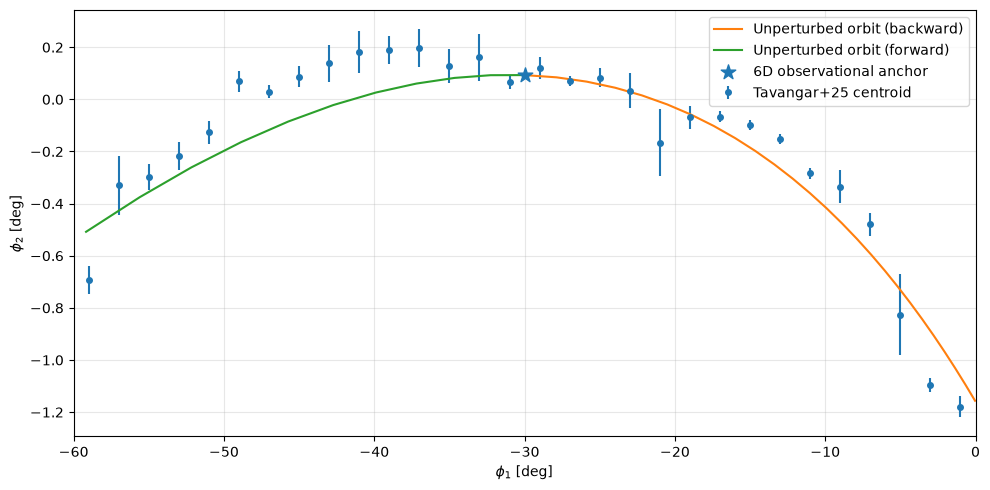

In [164]:
plt.figure(figsize=(10, 5))

# Tavangar+25 observed centroid
plt.errorbar(
    gd1_profiles["phi1"],
    gd1_profiles["phi2_med"],
    yerr=gd1_profiles["phi2_med_err"],
    fmt="o",
    ms=4,
    label="Tavangar+25 centroid"
)

# Backward orbit
backward_mask = (
    (backward_phi1 >= -60) &
    (backward_phi1 <= 0)
)

plt.plot(
    backward_phi1[backward_mask],
    backward_phi2[backward_mask],
    label="Unperturbed orbit (backward)"
)

# Forward orbit
forward_mask = (
    (forward_phi1 >= -60) &
    (forward_phi1 <= 0)
)

plt.plot(
    forward_phi1[forward_mask],
    forward_phi2[forward_mask],
    label="Unperturbed orbit (forward)"
)

# Observational anchor
plt.scatter(
    [target_phi1],
    [phi2_anchor],
    marker="*",
    s=120,
    zorder=5,
    label="6D observational anchor"
)

plt.xlim(-60, 0)

plt.xlabel(r"$\phi_1$ [deg]")
plt.ylabel(r"$\phi_2$ [deg]")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Forward branch: φ₁ = -30° → 0°

For the adopted GD-1 coordinate convention, the orbit integrated backward in time
moves from the anchor toward increasing φ₁.

The anchor orbit reproduces part of the observed large-scale φ₂ trend reasonably
well, but systematic offsets remain.

This agreement is used only as a zeroth-order dynamical check. It does not imply
that the observed stream is a single orbit: a tidal stream contains stars with a
distribution of orbital energies and actions, and its centroid need not coincide
with the progenitor orbit.

### Forward-in-time branch: φ₁ = -30° → -60°

For the adopted GD-1 coordinate convention, the orbit integrated forward in time
moves from the anchor toward decreasing φ₁.

The discrepancy with the observed Tavangar et al. (2025) centroid becomes larger on
this branch, reaching several tenths of a degree in φ₂.

This gives an important methodological result:

A single orbit initialized at one local observational anchor does not provide an adequate global description of the observed GD-1 stream.

We therefore do not force a global five-parameter orbit fit. The smooth orbit is
retained as a reference trajectory, while the main dynamical model is upgraded to
an extended tidal stream.

## Smooth orbit as a zeroth-order GD-1 dynamical reference

The observational anchor defines a physically motivated local six-dimensional phase-
space point at $(\phi_1=-30^\circ)$.

We now use this point to construct a smooth orbit in the adopted Milky Way potential.
The purpose is not to obtain a definitive global GD-1 orbit.

Instead, the orbit provides:

1. a numerical validation of the coordinate transformations and integration;
2. a physically motivated large-scale progenitor trajectory;
3. an initialization/reference trajectory for the subsequent tidal-stream model.

The orbit is therefore deliberately kept separate from the main stream inference.

### Observational anchor for the reference orbit

At $(\phi_1=-30^\circ)$, the six-dimensional anchor is constructed from the
observational baseline:

- $(\phi_2)$: Tavangar et al. (2025) centroid;
- distance: de Boer et al. (2020) fiducial distance track;
- $(\mu_1,\mu_2)$: Tavangar et al. (2025);
- $(v_r)$: Tavangar et al. (2025).

The earlier galstreams I21 radial-velocity track is not used as an observational
RV constraint. The anchor therefore remains tied to the actual observational
products adopted in this project.

### Reference-orbit construction

For a given local phase-space state, the orbit is integrated from \(t=0\) in both
time directions, transformed back to the GD-1 stream coordinate system, and combined
into the corresponding $(\phi_1)$ branches.

The branch-aware construction is retained because it will later provide the
progenitor trajectory used by the particle-spray stream model.

In [165]:
def build_orbit_track(theta):
    """
    Construct the local GD-1 orbit from five phase-space
    parameters at fixed phi1 = -30 deg.

    The integration is performed from t=0 in both directions.
    For the adopted GD-1 coordinate convention, forward time
    moves toward decreasing phi1, while backward time moves
    toward increasing phi1.
    """

    distance_kpc, phi2_deg, pm1_masyr, pm2_masyr, rv_kms = theta

    
    # Construct trial phase-space point

    trial_stream = coord.SkyCoord(
        phi1=target_phi1 * u.deg,
        phi2=phi2_deg * u.deg,
        distance=distance_kpc * u.kpc,
        pm_phi1_cosphi2=pm1_masyr * u.mas/u.yr,
        pm_phi2=pm2_masyr * u.mas/u.yr,
        radial_velocity=rv_kms * u.km/u.s,
        frame=gd1_i21.stream_frame
    )

    trial_icrs = trial_stream.transform_to(coord.ICRS())

    trial_gc = trial_icrs.transform_to(
        coord.Galactocentric()
    )

    w_trial = gd.PhaseSpacePosition(
        pos=trial_gc.cartesian.xyz,
        vel=trial_gc.velocity.d_xyz
    )

    
    # Integrate forward and backward from t = 0

    orbit_forward = mw.integrate_orbit(
        w_trial,
        dt=1 * u.Myr,
        t1=0 * u.Myr,
        t2=150 * u.Myr
    )

    orbit_backward = mw.integrate_orbit(
        w_trial,
        dt=-1 * u.Myr,
        t1=0 * u.Myr,
        t2=-150 * u.Myr
    )


    # Transform to GD-1 coordinates

    forward_gd1 = orbit_forward.to_coord_frame(
        coord.ICRS()
    ).transform_to(
        gd1_i21.stream_frame
    )

    backward_gd1 = orbit_backward.to_coord_frame(
        coord.ICRS()
    ).transform_to(
        gd1_i21.stream_frame
    )

    
    # Extract observables

    def extract(track):
        return {
            "phi1": track.phi1.to_value(u.deg),
            "phi2": track.phi2.to_value(u.deg),
            "distance": track.distance.to_value(u.kpc),
            "pm1": track.pm_phi1_cosphi2.to_value(u.mas/u.yr),
            "pm2": track.pm_phi2.to_value(u.mas/u.yr),
            "rv": track.radial_velocity.to_value(u.km/u.s),
        }

    f = extract(forward_gd1)
    b = extract(backward_gd1)



    forward_mask = (
        (f["phi1"] >= -60.0) &
        (f["phi1"] <= target_phi1)
    )

    backward_mask = (
        (b["phi1"] >= target_phi1) &
        (b["phi1"] <= 0.0)
    )

    forward_indices = np.where(forward_mask)[0][::-1]
    backward_indices = np.where(backward_mask)[0]

    # Require enough points on both local branches
    if len(forward_indices) < 2:
        raise ValueError(
            f"Forward branch does not cover -60 < phi1 < -30. "
            f"Only {len(forward_indices)} points found."
        )

    if len(backward_indices) < 2:
        raise ValueError(
            f"Backward branch does not cover -30 < phi1 < 0. "
            f"Only {len(backward_indices)} points found."
        )

    
    # Combine into increasing phi1

    result = {
        "phi1": np.concatenate([
            f["phi1"][forward_indices],
            b["phi1"][backward_indices][1:]
        ]),

        "phi2": np.concatenate([
            f["phi2"][forward_indices],
            b["phi2"][backward_indices][1:]
        ]),

        "distance": np.concatenate([
            f["distance"][forward_indices],
            b["distance"][backward_indices][1:]
        ]),

        "pm1": np.concatenate([
            f["pm1"][forward_indices],
            b["pm1"][backward_indices][1:]
        ]),

        "pm2": np.concatenate([
            f["pm2"][forward_indices],
            b["pm2"][backward_indices][1:]
        ]),

        "rv": np.concatenate([
            f["rv"][forward_indices],
            b["rv"][backward_indices][1:]
        ]),
    }

    return result

In [166]:

# Validate the orbit model using the observational anchor

theta_anchor = np.array([
    distance_anchor,
    phi2_anchor,
    pm1_anchor,
    pm2_anchor,
    rv_anchor
])

anchor_model = build_orbit_track(theta_anchor)

print("Anchor-model track")
print("------------------")

print(
    "phi1 range:",
    anchor_model["phi1"].min(),
    "to",
    anchor_model["phi1"].max()
)

print(
    "Number of model points:",
    len(anchor_model["phi1"])
)


# Interpolate model back to the anchor

anchor_phi2_check = np.interp(
    target_phi1,
    anchor_model["phi1"],
    anchor_model["phi2"]
)

anchor_dist_check = np.interp(
    target_phi1,
    anchor_model["phi1"],
    anchor_model["distance"]
)

anchor_pm1_check = np.interp(
    target_phi1,
    anchor_model["phi1"],
    anchor_model["pm1"]
)

anchor_pm2_check = np.interp(
    target_phi1,
    anchor_model["phi1"],
    anchor_model["pm2"]
)

anchor_rv_check = np.interp(
    target_phi1,
    anchor_model["phi1"],
    anchor_model["rv"]
)

print("\nAnchor recovery")
print("---------------")
print("phi1     =", target_phi1)
print("phi2     =", anchor_phi2_check)
print("distance =", anchor_dist_check)
print("pm1      =", anchor_pm1_check)
print("pm2      =", anchor_pm2_check)
print("rv       =", anchor_rv_check)

Anchor-model track
------------------
phi1 range: -59.17165166472029 to -0.02985688353265914
Number of model points: 36

Anchor recovery
---------------
phi1     = -30.0
phi2     = 0.09310877552245891
distance = 7.62
pm1      = -12.780140634528538
pm2      = -3.004756144863363
rv       = -86.55835993858051


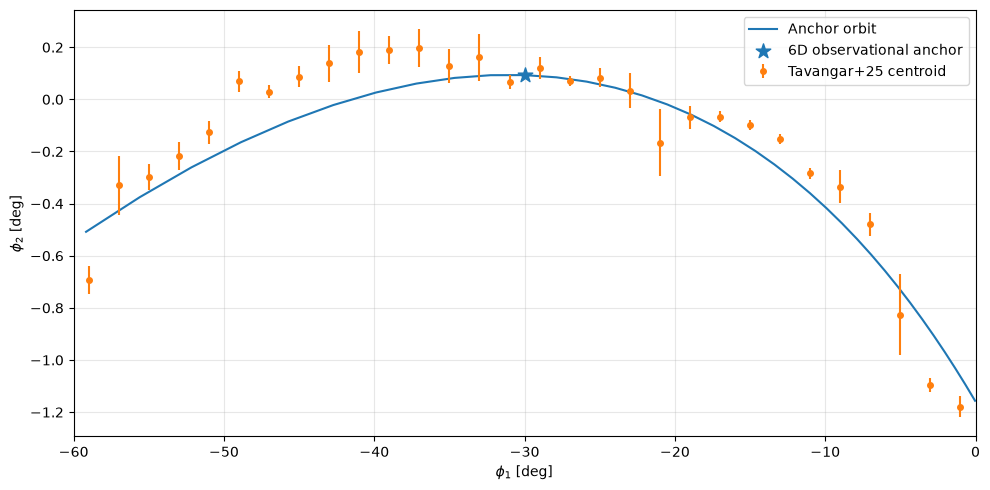

In [167]:
plt.figure(figsize=(10, 5))

plt.plot(
    anchor_model["phi1"],
    anchor_model["phi2"],
    label="Anchor orbit"
)

plt.errorbar(
    gd1_profiles["phi1"],
    gd1_profiles["phi2_med"],
    yerr=gd1_profiles["phi2_med_err"],
    fmt="o",
    ms=4,
    label="Tavangar+25 centroid"
)

plt.scatter(
    [target_phi1],
    [phi2_anchor],
    marker="*",
    s=120,
    zorder=5,
    label="6D observational anchor"
)

plt.xlim(-60, 0)

plt.xlabel(r"$\phi_1$ [deg]")
plt.ylabel(r"$\phi_2$ [deg]")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Quantify the anchor-orbit mismatch

The observational-anchor orbit is compared with the observed phase-space profiles
only as a diagnostic.

We calculate model-minus-observation residuals in

$
\Delta\phi_2,\quad
\Delta d,\quad
\Delta\mu_1,\quad
\Delta\mu_2,\quad
\Delta v_r.
$

These residuals are not used to define a best-fitting orbit.


In [168]:

# Quantify the observational-anchor orbit mismatch

def rms_residual(x_obs, y_obs, x_model, y_model):
    """RMS of model-minus-observation residuals at observed x positions."""
    x_obs = np.asarray(x_obs, dtype=float)
    y_obs = np.asarray(y_obs, dtype=float)
    x_model = np.asarray(x_model, dtype=float)
    y_model = np.asarray(y_model, dtype=float)

    mask = np.isfinite(x_obs) & np.isfinite(y_obs)
    x = x_obs[mask]
    y = y_obs[mask]

    inside = (x >= np.min(x_model)) & (x <= np.max(x_model))
    x = x[inside]
    y = y[inside]

    if len(x) == 0:
        return {"N": 0, "RMS": np.nan, "median": np.nan}

    y_pred = np.interp(x, x_model, y_model)
    residual = y_pred - y

    return {
        "N": len(residual),
        "RMS": np.sqrt(np.mean(residual**2)),
        "median": np.median(residual),
    }


theta_anchor = np.array([
    distance_anchor,
    phi2_anchor,
    pm1_anchor,
    pm2_anchor,
    rv_anchor,
])

anchor_model = build_orbit_track(theta_anchor)

diagnostics = {
    "phi2": rms_residual(
        gd1_profiles["phi1"],
        gd1_profiles["phi2_med"],
        anchor_model["phi1"],
        anchor_model["phi2"],
    ),
    "distance": rms_residual(
        phi1_deboer[(phi1_deboer >= -60) & (phi1_deboer <= 0)],
        distance_deboer[(phi1_deboer >= -60) & (phi1_deboer <= 0)],
        anchor_model["phi1"],
        anchor_model["distance"],
    ),
    "pm1": rms_residual(
        gd1_profiles["phi1"],
        gd1_profiles["pm1_med"],
        anchor_model["phi1"],
        anchor_model["pm1"],
    ),
    "pm2": rms_residual(
        gd1_profiles["phi1"],
        gd1_profiles["pm2_med"],
        anchor_model["phi1"],
        anchor_model["pm2"],
    ),
}

rv_mask = (
    (gd1_profiles["N_rv"] >= 5) &
    np.isfinite(gd1_profiles["rv_med"])
)

diagnostics["rv"] = rms_residual(
    gd1_profiles.loc[rv_mask, "phi1"],
    gd1_profiles.loc[rv_mask, "rv_med"],
    anchor_model["phi1"],
    anchor_model["rv"],
)

print("Anchor-orbit mismatch diagnostics")
print("=================================")

units = {
    "phi2": "deg",
    "distance": "kpc",
    "pm1": "mas/yr",
    "pm2": "mas/yr",
    "rv": "km/s",
}

for name, result in diagnostics.items():
    print(
        f"{name:9s}: "
        f"N={result['N']:3d}, "
        f"RMS={result['RMS']:.4f} {units[name]}, "
        f"median={result['median']:.4f} {units[name]}"
    )

Anchor-orbit mismatch diagnostics
phi2     : N= 30, RMS=0.1190 deg, median=-0.0711 deg
distance : N=  6, RMS=1.6242 kpc, median=0.0577 kpc
pm1      : N= 30, RMS=1.9910 mas/yr, median=0.0051 mas/yr
pm2      : N= 30, RMS=0.4264 mas/yr, median=0.0198 mas/yr
rv       : N= 24, RMS=5.6465 km/s, median=0.7825 km/s


### Interpretation of the orbit diagnostic

The smooth orbit provides the dynamical reference frame and captures the broad
motion of the system, but its residual structure demonstrates the limitation of
treating GD-1 as a one-dimensional trajectory.

We therefore make a deliberate methodological transition:

- Galactic potential
- progenitor orbit
- tidal stream
- perturbed stream

The observed stream will not be forced to lie on the reference orbit. Instead, the
next model will generate an ensemble of stripped particles whose collective
phase-space distribution can be compared with the observations.

## 13. Downstream handoff: export the observational baseline

Notebook 02 should use the results of this notebook explicitly rather than relying
on a shared Jupyter namespace. The cells below export the exact variables produced
by Notebook 01 into a small, portable handoff directory.

This keeps the notebooks reproducible while still allowing the same `.venv` to be
used by every notebook.


In [169]:
# ============================================================
# Export the Notebook 01 baseline for downstream notebooks
# ============================================================

from pathlib import Path
import json
import pandas as pd
import numpy as np

# Project root: adjust ONLY if your repository lives elsewhere.
PROJECT_ROOT = Path("/home/darxsouls/research/stellar_streams")
HANDOFF_DIR = PROJECT_ROOT / "data" / "derived" / "notebook01_handoff"
HANDOFF_DIR.mkdir(parents=True, exist_ok=True)

# 1. Observational GD-1 profiles: this is the exact DataFrame
#    constructed above in Notebook 01.
gd1_profiles.to_csv(HANDOFF_DIR / "gd1_profiles.csv", index=False)

# 2. Fiducial de Boer distance track.
#    These are the exact arrays used above in Notebook 01.
distance_table = pd.DataFrame({
    "phi1_deg": np.asarray(phi1_deboer, dtype=float),
    "distance_kpc": np.asarray(distance_deboer, dtype=float),
    "distance_err_kpc": np.asarray(distance_err_deboer, dtype=float),
})
distance_table.to_csv(HANDOFF_DIR / "gd1_distance_deboer.csv", index=False)

# 3. Validated 6-D observational anchor.
anchor = {
    "phi1_deg": float(target_phi1),
    "phi2_deg": float(phi2_anchor),
    "distance_kpc": float(distance_anchor),
    "pm1_masyr": float(pm1_anchor),
    "pm2_masyr": float(pm2_anchor),
    "rv_kms": float(rv_anchor),
    "galactocentric_position_kpc": gd1_anchor_gc_obs.cartesian.xyz.to_value(u.kpc).tolist(),
    "galactocentric_velocity_kms": gd1_anchor_gc_obs.velocity.d_xyz.to_value(u.km/u.s).tolist(),
}
with open(HANDOFF_DIR / "gd1_anchor.json", "w") as f:
    json.dump(anchor, f, indent=2)

# 4. Model/analysis metadata.
metadata = {
    "milky_way_potential": "gala.MilkyWayPotential(version='v2')",
    "galactocentric_frame_defaults": "v4.0",
    "main_phi1_range_deg": [-60.0, 0.0],
    "profile_bin_width_deg": 2.0,
    "anchor_phi1_deg": float(target_phi1),
}
with open(HANDOFF_DIR / "baseline_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Notebook 01 handoff exported to:")
print(HANDOFF_DIR.resolve())
for path in sorted(HANDOFF_DIR.iterdir()):
    print("  ✓", path.name)


Notebook 01 handoff exported to:
/home/darxsouls/research/stellar_streams/data/derived/notebook01_handoff
  ✓ baseline_metadata.json
  ✓ gd1_anchor.json
  ✓ gd1_distance_deboer.csv
  ✓ gd1_profiles.csv


In [170]:
# Verify the downstream handoff
required = [
    "gd1_profiles.csv",
    "gd1_distance_deboer.csv",
    "gd1_anchor.json",
    "baseline_metadata.json",
]
missing = [name for name in required if not (HANDOFF_DIR / name).exists()]
if missing:
    raise FileNotFoundError(f"Missing handoff files: {missing}")

# Read back the key files to ensure they are actually usable.
check_profiles = pd.read_csv(HANDOFF_DIR / "gd1_profiles.csv")
check_distance = pd.read_csv(HANDOFF_DIR / "gd1_distance_deboer.csv")
with open(HANDOFF_DIR / "gd1_anchor.json") as f:
    check_anchor = json.load(f)

print("Handoff verification: PASS")
print("  profiles:", check_profiles.shape)
print("  distance:", check_distance.shape)
print("  anchor phi1:", check_anchor["phi1_deg"])


Handoff verification: PASS
  profiles: (30, 15)
  distance: (12, 3)
  anchor phi1: -30.0
